# Analýza spolehlivosti letecké dopravy USA (2022–2024)

**Semestrální práce – Business Intelligence & Business Analysis (Mgr.)**  
Dataset: *On-Time Reporting Carrier On-Time Performance*, BTS / U.S. Department of Transportation  
36 souborů CSV (leden 2022 – prosinec 2024)

---

## Business otázky

| # | Otázka | Entita | Klíčové KPI |
|---|--------|--------|-------------|
| **BQ1** | Jak se liší spolehlivost letů mezi jednotlivými dny v týdnu v období 2022–2024 a existují dny se systematicky vyšší mírou zpoždění? | DayOfWeek, typ dne | ArrDel15 Rate, Avg ArrDelayMinutes |
| **BQ2** | Existuje v období 2022–2024 vztah mezi délkou letu (vzdáleností) a mírou zpoždění příletu a jsou delší lety náchylnější ke zpoždění než krátké? | Kategorie vzdálenosti (Distance) | ArrDel15 Rate, Avg ArrDelayMinutes, Median ArrDelayMinutes |
| **BQ3** | Jaký je v období 2022–2024 vztah mezi zpožděním odletu a zpožděním příletu a do jaké míry jsou dopravci schopni zpoždění během letu kompenzovat? | Dopravce (Reporting_Airline), let | Avg DepDelayMinutes, Avg ArrDelayMinutes, Avg Delay Difference |
| **BQ4** | Jak stabilní je výkon jednotlivých dopravců v čase (2022–2024) a dochází k výrazným výkyvům ve spolehlivosti mezi měsíci? | Dopravce, měsíc/rok | ArrDel15 Rate, Avg ArrDelayMinutes, StdDev ArrDelayMinutes |

---

In [132]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

# Nastav pracovní adresář na složku s notebookem (VS Code spouští kernel jinak)
try:
    os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
except NameError:
    pass  # JupyterLab / klasický Jupyter – CWD je již správně nastaven

print(f"Pracovní adresář: {os.getcwd()}")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10
})

# Výstupní složky
PLOTS_DIR = "plots"
DATA_DIR  = "data"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,  exist_ok=True)

# Pomocné mapy
DAY_NAMES = {1: "Po", 2: "Út", 3: "St", 4: "Čt", 5: "Pá", 6: "So", 7: "Ne"}
MONTH_NAMES = {1:"Led",2:"Úno",3:"Bře",4:"Dub",5:"Kvě",6:"Čvn",
               7:"Čvc",8:"Srp",9:"Zář",10:"Říj",11:"Lis",12:"Pro"}
MONTH_LABELS = {
    202201:"01/22",202202:"02/22",202203:"03/22",202204:"04/22",
    202205:"05/22",202206:"06/22",202207:"07/22",202208:"08/22",
    202209:"09/22",202210:"10/22",202211:"11/22",202212:"12/22",
    202301:"01/23",202302:"02/23",202303:"03/23",202304:"04/23",
    202305:"05/23",202306:"06/23",202307:"07/23",202308:"08/23",
    202309:"09/23",202310:"10/23",202311:"11/23",202312:"12/23",
    202401:"01/24",202402:"02/24",202403:"03/24",202404:"04/24",
    202405:"05/24",202406:"06/24",202407:"07/24",202408:"08/24",
    202409:"09/24",202410:"10/24",202411:"11/24",202412:"12/24"
}


Pracovní adresář: /Users/marektatyrek/SynologyDrive/TECHNIC/SCHOOL/VUT/PŘEDMĚTY/10.SEMESTR/FP/BI/Solution


In [133]:
# === Rychlé načtení dat z cache ===
# Spusťte tuto buňku MÍSTO buněk c05–c25 (ETL + calc),
# pokud jste notebook již jednou celý prošli a CSV soubory existují v DATA_DIR.

_cache_files = [
    "bq1.csv", "bq1_seasonal.csv",
    "bq2.csv", "bq2_dist.csv", "bq2_seasonal.csv", "bq2_types.csv",
    "bq3.csv", "bq3_all.csv", "bq3_seasonal.csv",
    "bq4_monthly.csv", "bq4_summary_all.csv",
]
_missing = [f for f in _cache_files if not os.path.exists(os.path.join(DATA_DIR, f))]

if _missing:
    print("✗ Cache nekompletní – chybí:", _missing)
    print("  Spusťte nejprve celý notebook (buňky c05–c25), poté se data uloží automaticky.")
else:
    def _csv(name):
        return pd.read_csv(os.path.join(DATA_DIR, name))

    bq1             = _csv("bq1.csv")
    bq1_seasonal    = _csv("bq1_seasonal.csv")
    bq2             = _csv("bq2.csv")
    bq2_dist        = _csv("bq2_dist.csv")
    bq2_seasonal    = _csv("bq2_seasonal.csv")
    bq2_types       = _csv("bq2_types.csv")
    bq3             = _csv("bq3.csv")
    bq3_all         = _csv("bq3_all.csv")
    bq3_all["Tier"] = bq3_all["Tier"].astype(int)
    bq3_seasonal    = _csv("bq3_seasonal.csv")
    bq4_monthly     = _csv("bq4_monthly.csv")
    bq4_summary_all = _csv("bq4_summary_all.csv")

    TOP10 = list(bq3["Reporting_Airline"].unique())

    print("✓ Data načtena z cache. Grafy lze vykreslovat bez spouštění ETL pipeline.")


✗ Cache nekompletní – chybí: ['bq1.csv', 'bq1_seasonal.csv', 'bq2.csv', 'bq2_dist.csv', 'bq2_seasonal.csv', 'bq2_types.csv', 'bq3.csv', 'bq3_all.csv', 'bq3_seasonal.csv', 'bq4_monthly.csv', 'bq4_summary_all.csv']
  Spusťte nejprve celý notebook (buňky c05–c25), poté se data uloží automaticky.


---
## 1. ETL – Extract: Načtení dat

**Logika integrace:**  
Všechny měsíční soubory jsou načteny hromadně z adresáře `../Data/` pomocí `glob` a sloučeny operací `concat` (append).  
Z názvu souboru jsou implicitně dostupné atributy `Year` a `Month` přítomné přímo v datech.  
Před sloučením načítáme pouze vybrané sloupce (projekce) aby se minimalizovala paměťová náročnost.

**Validace pokrytí:** Ověřujeme, že jsou přítomny záznamy pro všech 36 měsíců (2022-01 až 2024-12).

In [134]:
RAW_DIR = "../Data/"
files = sorted(glob.glob(RAW_DIR + "*.csv"))
print(f"Nalezeno CSV souborů: {len(files)}")

# Sloupce relevantní pro všechny 4 business otázky + typy zpoždění
COLS = [
    "Year", "Month", "DayOfWeek",
    "Reporting_Airline",
    "DepDelayMinutes", "ArrDelayMinutes", "ArrDel15",
    "Cancelled", "Diverted",
    "Distance",
    # Typy zpoždění (minuty přiřazené jednotlivým příčinám)
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"
]

chunks = []
skipped = []
for f in files:
    try:
        chunk = pd.read_csv(f, usecols=COLS, low_memory=False)
        chunks.append(chunk)
    except ValueError:
        skipped.append(f)

if skipped:
    print(f"Přeskočeno {len(skipped)} souborů (neodpovídají schématu): {[os.path.basename(s) for s in skipped]}")

print(f"Načteno souborů: {len(chunks)}")
df_raw = pd.concat(chunks, ignore_index=True)
print(f"\nCelkem řádků (raw): {len(df_raw):,}")
print(f"Pokrytí let: {df_raw['Year'].min()}–{df_raw['Year'].max()}")

# Kontrolní tabulka: počet záznamů po měsících
coverage = df_raw.groupby(["Year", "Month"]).size().unstack("Month")
print(f"\nPokrytí měsíců (počet řádků):")
print(coverage.to_string())

expected_months = 36
actual_months = df_raw.groupby(["Year", "Month"]).ngroups
print(f"\nOčekávaný počet měsíců: {expected_months}, načteno: {actual_months} → {'OK' if actual_months == expected_months else 'CHYBA – chybí měsíce!'}")


Nalezeno CSV souborů: 47
Přeskočeno 11 souborů (neodpovídají schématu): ['bq1.csv', 'bq1_seasonal.csv', 'bq2.csv', 'bq2_dist.csv', 'bq2_seasonal.csv', 'bq2_types.csv', 'bq3.csv', 'bq3_all.csv', 'bq3_seasonal.csv', 'bq4_monthly.csv', 'bq4_summary_all.csv']
Načteno souborů: 36

Celkem řádků (raw): 20,656,085
Pokrytí let: 2022–2024

Pokrytí měsíců (počet řádků):
Month      1       2       3       4       5       6       7       8       9       10      11      12
Year                                                                                                 
2022   537902  495713  564853  556502  578819  577283  594957  589810  557494  572287  546410  557095
2023   538837  502749  580322  561441  579958  577262  601866  602987  569338  598968  563777  570394
2024   547271  519221  591767  582185  609743  611132  634613  619025  582622  615497  575404  590581

Očekávaný počet měsíců: 36, načteno: 36 → OK


---
## 2. ETL – Transform: Čištění a příprava dat

**ETL logika (3 kroky):**

**Extract:** Automatické načtení všech 36 souborů z adresáře, projekce na relevantní sloupce.

**Transform:**
- Oddělení zrušených letů (`Cancelled=1`) – pro ně nejsou platná časová data ani zpoždění; místo toho jsou sledovány separátním KPI *Cancellation Rate*.
- Převod datových typů a výpočet odvozených atributů: `DayType`, `DayName`, `DistanceCat`, `DelayDiff`.
- Ošetření chybějících hodnot dle metadat (viz sekce 2.3).

**Load:** Výstupem je `df_ops` – čistý dataset operačních letů připravený pro KPI výpočty.

In [135]:
# --- SEPARÁTNÍ KPI: Cancellation Rate (před filtrací) ---
cancelled_summary = df_raw.groupby(["Year", "Month"]).agg(
    TotalFlights=("Cancelled", "count"),
    CancelledFlights=("Cancelled", "sum")
).reset_index()
cancelled_summary["CancellationRate"] = (
    cancelled_summary["CancelledFlights"] / cancelled_summary["TotalFlights"] * 100
)

# --- FILTR: Pouze uskutečněné lety (Cancelled=0, Diverted=0) ---
# Zdůvodnění: Metadata říkají, že pro Cancelled=1 nejsou skutečné časy ani zpoždění relevantní.
# Přesměrované lety (Diverted=1) mají neúplné záznamy o zpoždění příletu.
df_ops = df_raw[(df_raw["Cancelled"] == 0) & (df_raw["Diverted"] == 0)].copy()

# --- ČIŠTĚNÍ: Odstranění záznamů s chybějícími delay hodnotami ---
# DepDelayMinutes a ArrDelayMinutes jsou předpočítané metriky (nikoliv hrubé časy);
# záznamy bez těchto hodnot u nezkrušených letů jsou datově nekompletní.
df_ops = df_ops.dropna(subset=["ArrDelayMinutes", "DepDelayMinutes", "Distance"])

# --- ArrDel15: doplnění z ArrDelayMinutes kde chybí ---
mask_null_del15 = df_ops["ArrDel15"].isna()
df_ops.loc[mask_null_del15, "ArrDel15"] = (
    df_ops.loc[mask_null_del15, "ArrDelayMinutes"] >= 15
).astype(float)

# --- ODVOZENÉ ATRIBUTY ---

# Typ dne (DayOfWeek >= 6 = víkend)
df_ops["DayType"] = np.where(df_ops["DayOfWeek"] >= 6, "Víkend", "Pracovní den")
df_ops["DayName"] = df_ops["DayOfWeek"].map(DAY_NAMES)

# Kategorie délky letu dle vzdálenosti (miles)
bins = [0, 500, 1500, np.inf]
labels = ["Krátký (<500 mi)", "Střední (500–1500 mi)", "Dlouhý (>1500 mi)"]
df_ops["DistanceCat"] = pd.cut(df_ops["Distance"], bins=bins, labels=labels)

# Rozdíl zpoždění: kladná hodnota = zpoždění se zhoršilo, záporná = dopravce "dohnal" zpoždění
df_ops["DelayDiff"] = df_ops["ArrDelayMinutes"] - df_ops["DepDelayMinutes"]

# YearMonth klíč pro časové osy
df_ops["YearMonth"] = df_ops["Year"] * 100 + df_ops["Month"]

# --- TOP 10 dopravců dle počtu letů (pro BQ3 a BQ4) ---
TOP10 = df_ops["Reporting_Airline"].value_counts().head(10).index.tolist()

print(f"Celkem letů v df_raw:      {len(df_raw):>12,}")
print(f"Zrušené lety (Cancelled=1): {df_raw['Cancelled'].sum():>11,}  "
      f"({df_raw['Cancelled'].mean()*100:.2f}%)")
print(f"Přesměrované (Diverted=1):  {df_raw['Diverted'].sum():>11,}  "
      f"({df_raw['Diverted'].mean()*100:.2f}%)")
print(f"\nZáznamy v df_ops (čistý):  {len(df_ops):>12,}  "
      f"({len(df_ops)/len(df_raw)*100:.1f}% z celku)")
print(f"\nTop 10 dopravců: {TOP10}")
print(f"\nRozdělení dle kategorie délky letu:")
print(df_ops["DistanceCat"].value_counts().sort_index())

Celkem letů v df_raw:        20,656,085
Zrušené lety (Cancelled=1):   365,544.0  (1.77%)
Přesměrované (Diverted=1):     49,877.0  (0.24%)

Záznamy v df_ops (čistý):    20,240,662  (98.0% z celku)

Top 10 dopravců: ['WN', 'DL', 'AA', 'OO', 'UA', 'YX', 'B6', 'MQ', 'NK', 'AS']

Rozdělení dle kategorie délky letu:
DistanceCat
Krátký (<500 mi)          7103795
Střední (500–1500 mi)    10569082
Dlouhý (>1500 mi)         2567785
Name: count, dtype: int64


---
## 2.3 Data Quality & Cleaning Decisions

| Oblast | Problém / zjištění | Dopad na KPI | Pravidlo / řešení | Zdůvodnění (vazba na metadata) | Kontrola |
|--------|-------------------|-------------|-------------------|-------------------------------|----------|
| **Integrace** | Různé datové typy sloupců v různých měsících (číslo vs. text) | Chybné agregace, selhání výpočtu KPI | `low_memory=False` při načtení; sloupce zpracovány přes pandas dtype inference | Metadata definují typy (int/float/string); nízká paměťová optimalizace odstraní false-positive typové konflikty | Kontrola `df.dtypes` po načtení |
| **Pokrytí** | Nutno ověřit přítomnost všech 36 měsíců | Zkreslení trendů a YoY srovnání | Kontrolní tabulka počtu řádků po roce × měsíci | Analýza 3 let vyžaduje úplné pokrytí | Výpis `coverage` v ETL buňce |
| **Cancelled=1** | Pro zrušené lety chybí skutečné časy a zpoždění (NULL nebo nesmyslné) | Průměrné zpoždění by vycházelo zkresleně | Zrušené lety vyloučeny z delay KPI; sledovány jako separátní KPI `CancellationRate` | Metadata uvádějí, že u `Cancelled=1` nejsou pole `ArrDelayMinutes`, `DepDelayMinutes` relevantní | Porovnání počtu NULL v delay sloupcích pro `Cancelled=0` vs `Cancelled=1` |
| **Diverted=1** | Přesměrované lety nemají kompletní záznam zpoždění příletu | Zkreslení ArrDelay KPI | Vyloučení `Diverted=1` z operačního datasetu | Metadata: `ArrDelayMinutes` je pro přesměrované lety neúplné / irelevantní | Počet NULL `ArrDelayMinutes` u `Diverted=0` vs `Diverted=1` |
| **NULL v ArrDelayMinutes** | Některé nekrušené lety mají NULL v `ArrDelayMinutes` | Podhodnocení počtu záznamů; zkreslení průměru | Řádky s NULL `ArrDelayMinutes` (nebo `DepDelayMinutes`) vyloučeny z df_ops | Bez hodnoty zpoždění nelze počítat žádný delay KPI | Kontrola: `df_ops['ArrDelayMinutes'].isna().sum()` = 0 |
| **ArrDel15 NULL** | Atribut `ArrDel15` může chybět i pro nekrušené lety | Podhodnocení ArrDel15 Rate | Doplnění z `ArrDelayMinutes >= 15` kde `ArrDel15` je NULL | Metadata definují `ArrDel15 = 1` iff `ArrDelayMinutes >= 15`; přímé odvození je ekvivalentní | Kontrola shody: porovnání odvozeného vs. původního `ArrDel15` |
| **Záporné DepDelayMinutes** | Předčasné odlety mají záporné hodnoty | Průměr předčasných odletů snižuje průměrné zpoždění | Záporné hodnoty **nejsou odstraněny** – jsou součástí distribuce a relevantní pro BQ3 (kompenzace zpoždění) | Metadata: `DepDelayMinutes` = 0 pro brzy odlétající (early departure ≠ delay), ale `ArrDelayMinutes` může být záporné pro rané přílety | Uvádět medián vedle průměru pro robustní interpretaci |
| **Outliery v ArrDelayMinutes** | Extrémní hodnoty (>500 min) výrazně zvedají průměr | Průměr není robustní metrika při silně asymetrickém rozdělení | Outliery nejsou odstraněny; KPI2 (BQ2) zahrnuje medián jako robustní alternativu | Outliery jsou reálné (technické závady, počasí); jejich odstranění by zkreslilo obraz dat | Vždy uvádět průměr + medián; u BQ2 porovnat oba |
| **Distance = NULL nebo 0** | Chybějící vzdálenost neumožňuje kategorizaci letu | Záznamy bez Distance nepatří do žádné distance kategorie; chyba v BQ2 | Řádky s NULL `Distance` vyloučeny v dropna(); případné Distance=0 by vypadly do první bin (ošetřeno prahem >0) | Distance je základní atribut záznamu; metadata ji definují jako povinnou numerickou hodnotu | `df_ops['Distance'].isna().sum()` = 0 po transformaci |

---
## BQ1 – Spolehlivost podle dne v týdnu

**Business otázka:** Jak se liší spolehlivost letů mezi jednotlivými dny v týdnu v období 2022–2024 a existují dny se systematicky vyšší mírou zpoždění?

**Hypotéza:** Provozní zatížení se liší mezi pracovními dny a víkendy. V pracovních dnech může být vyšší
hustota letů, což vede k vyšší pravděpodobnosti zpoždění.

**KPI:**
- `ArrDel15 Rate` = podíl letů s příletem ≥ 15 min po plánovaném čase (frekvence problému)
- `Avg ArrDelayMinutes` = průměrné zpoždění příletu (intenzita problému)

**Poznámka k metadatům:** `ArrDel15` je vypočítaná binární proměnná (1/0); pro výpočet KPI používáme pouze záznamy s `Cancelled=0` (viz DQ tabulka). Záporné hodnoty `ArrDelayMinutes` (brzy přílet) jsou zahrnuty do průměru – snižují jej, ale jsou validní součástí distribuce.

In [136]:
# --- BQ1: Výpočet KPI dle dne v týdnu ---
bq1 = df_ops.groupby("DayOfWeek").agg(
    TotalFlights=("ArrDel15", "count"),
    DelayedFlights=("ArrDel15", "sum"),
    AvgArrDelay=("ArrDelayMinutes", "mean"),
    AvgArrDelayWhenDelayed=("ArrDelayMinutes", lambda x: x[x > 0].mean()),
    MedianArrDelay=("ArrDelayMinutes", "median")
).reset_index()
bq1["ArrDel15Rate"] = bq1["DelayedFlights"] / bq1["TotalFlights"] * 100
bq1["DayName"] = bq1["DayOfWeek"].map(DAY_NAMES)
bq1 = bq1.sort_values("DayOfWeek")

print("KPI dle dne v týdnu (2022–2024):")
print(bq1[["DayName","TotalFlights","ArrDel15Rate","AvgArrDelay","AvgArrDelayWhenDelayed","MedianArrDelay"]]
      .to_string(index=False, float_format="{:.2f}".format))
print("\nAvgArrDelay           = průměr přes VŠECHNY lety (0 = včas)")
print("AvgArrDelayWhenDelayed = průměr pouze ze ZPOŽDĚNÝCH letů (ArrDelayMinutes > 0)")

bq1.to_csv(os.path.join(DATA_DIR, "bq1.csv"), index=False)
print(f"\n✓ Uloženo: {DATA_DIR}/bq1.csv")


KPI dle dne v týdnu (2022–2024):
DayName  TotalFlights  ArrDel15Rate  AvgArrDelay  AvgArrDelayWhenDelayed  MedianArrDelay
     Po       3023614         20.62        15.43                   42.13            0.00
     Út       2815092         17.67        12.99                   39.95            0.00
     St       2831836         18.73        13.70                   40.22            0.00
     Čt       2982041         21.79        15.97                   41.62            0.00
     Pá       3006991         23.39        17.32                   43.10            0.00
     So       2618318         20.56        15.66                   43.60            0.00
     Ne       2962770         22.63        16.94                   43.46            0.00

AvgArrDelay           = průměr přes VŠECHNY lety (0 = včas)
AvgArrDelayWhenDelayed = průměr pouze ze ZPOŽDĚNÝCH letů (ArrDelayMinutes > 0)

✓ Uloženo: data/bq1.csv


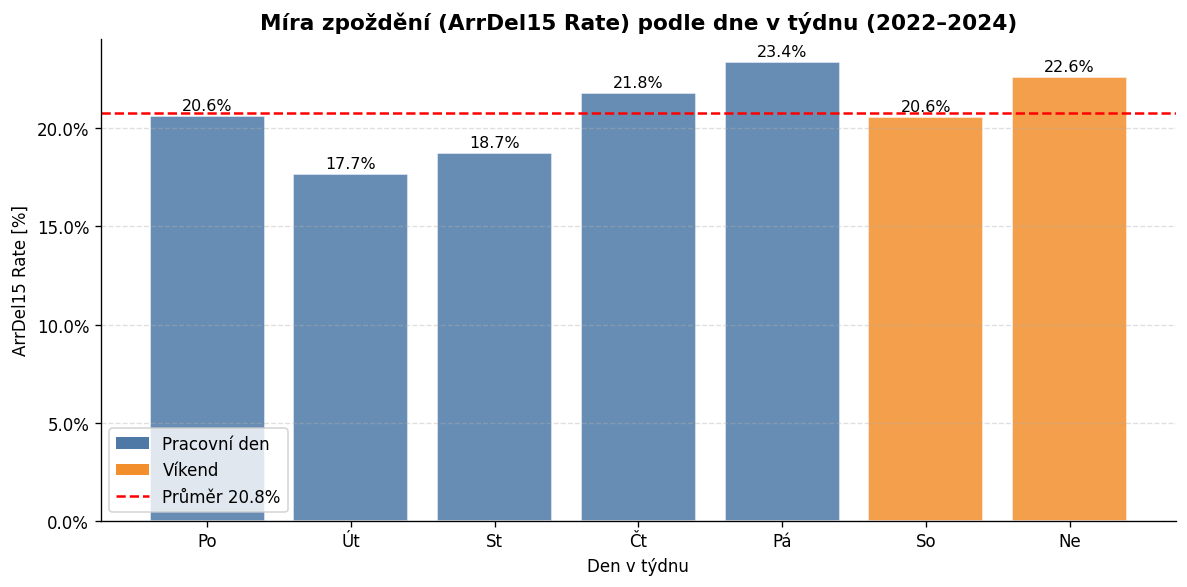

In [137]:
# BQ1 – Viz 1: Míra zpoždění dle dne v týdnu (sloupcový graf)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#f28e2b" if d >= 6 else "#4e79a7" for d in bq1["DayOfWeek"]]
bars = ax.bar(bq1["DayName"], bq1["ArrDel15Rate"], color=colors, alpha=0.85, edgecolor="white")
avg_rate = bq1["ArrDel15Rate"].mean()
ax.axhline(avg_rate, color="red", linestyle="--", linewidth=1.5, label=f"Průměr: {avg_rate:.1f}%")
for bar, val in zip(bars, bq1["ArrDel15Rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Míra zpoždění (ArrDel15 Rate) podle dne v týdnu (2022–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("ArrDel15 Rate [%]")
ax.set_xlabel("Den v týdnu")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#4e79a7", label="Pracovní den"),
    Patch(facecolor="#f28e2b", label="Víkend"),
    plt.Line2D([0],[0], color="red", linestyle="--", label=f"Průměr {avg_rate:.1f}%")
])
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq1_viz1_delay_by_weekday.png"), dpi=150, bbox_inches="tight")
plt.show()


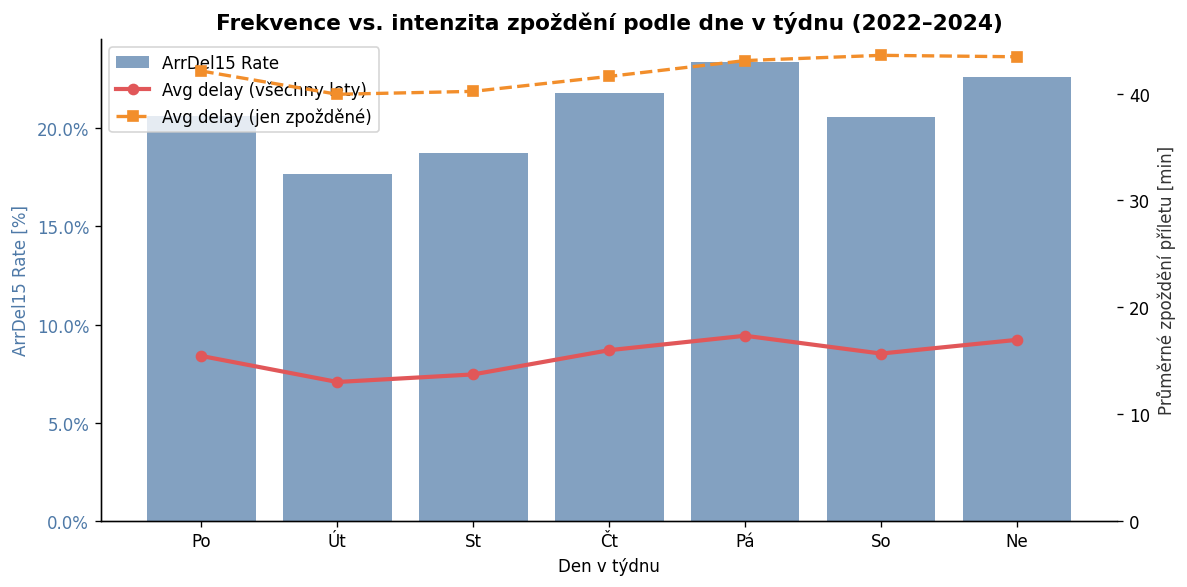

In [138]:
# BQ1 – Viz 2: Frekvence vs. intenzita zpoždění (kombinovaný graf)
# Pravá osa zobrazuje obě metriky: průměr přes všechny lety vs. jen zpožděné
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(bq1["DayName"], bq1["ArrDel15Rate"], color="#4e79a7", alpha=0.7, label="ArrDel15 Rate")
ax2.plot(bq1["DayName"], bq1["AvgArrDelay"], color="#e15759",
         marker="o", linewidth=2.5, label="Avg delay (všechny lety)", zorder=5)
ax2.plot(bq1["DayName"], bq1["AvgArrDelayWhenDelayed"], color="#f28e2b",
         marker="s", linewidth=2, linestyle="--", label="Avg delay (jen zpožděné)", zorder=5)

ax1.set_ylabel("ArrDel15 Rate [%]", color="#4e79a7")
ax2.set_ylabel("Průměrné zpoždění příletu [min]", color="#333333")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.tick_params(axis="y", labelcolor="#4e79a7")
ax2.set_ylim(bottom=0)
ax1.set_title("Frekvence vs. intenzita zpoždění podle dne v týdnu (2022–2024)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Den v týdnu")
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq1_viz2_frequency_vs_intensity.png"), dpi=150, bbox_inches="tight")
plt.show()


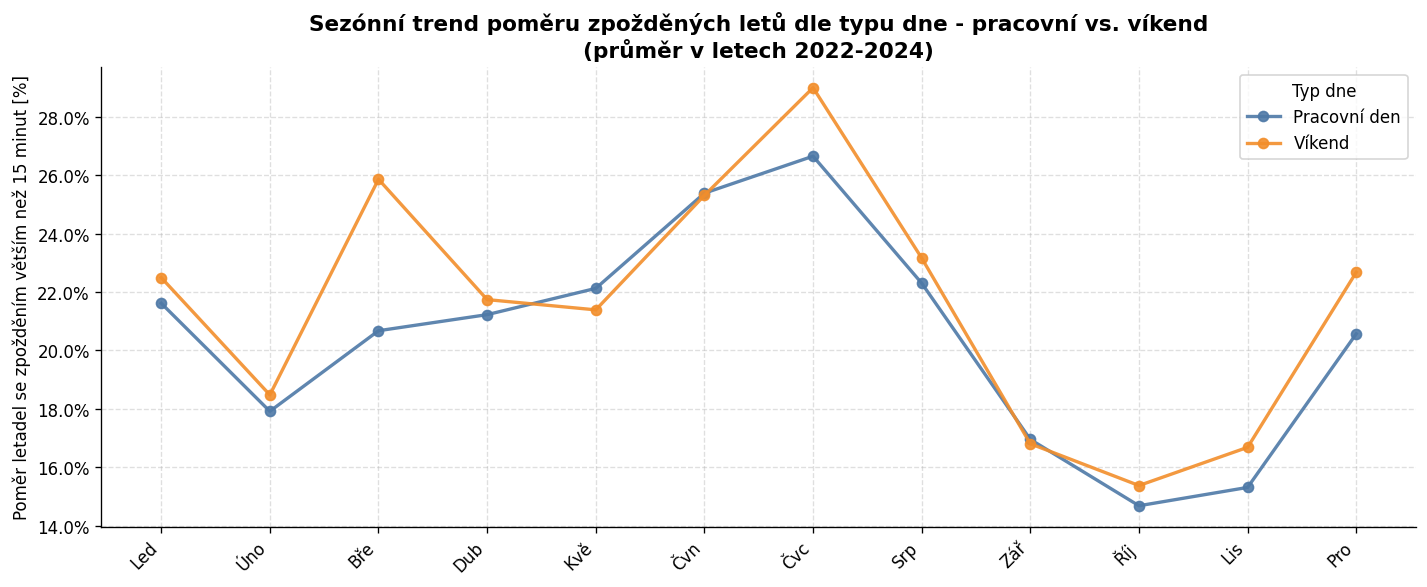

In [139]:
# BQ1 – Viz 3: Sezónní trend ArrDel15 Rate dle typu dne (průměr přes 2022–2024)
_f = os.path.join(DATA_DIR, "bq1_seasonal.csv")
if os.path.exists(_f):
    bq1_seasonal = pd.read_csv(_f)
else:
    bq1_seasonal = df_ops.groupby(["Month", "DayType"]).agg(
        ArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100)
    ).reset_index().sort_values("Month")
    bq1_seasonal.to_csv(_f, index=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_dt = {"Pracovní den": "#4e79a7", "Víkend": "#f28e2b"}
months = list(range(1, 13))
month_labels = [MONTH_NAMES[m] for m in months]

for dt, grp in bq1_seasonal.groupby("DayType"):
    grp_s = grp.sort_values("Month")
    ax.plot(grp_s["Month"], grp_s["ArrDel15Rate"],
            marker="o", linewidth=2, label=dt, color=colors_dt[dt], alpha=0.9)

ax.set_xticks(months)
ax.set_xticklabels(month_labels, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Sezónní trend poměru zpožděných letů dle typu dne - pracovní vs. víkend\n(průměr v letech 2022-2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Poměr letadel se zpožděním větším než 15 minut [%]")
ax.legend(title="Typ dne")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq1_viz3_seasonal_by_daytype.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## BQ2 – Vliv délky letu na zpoždění

**Business otázka:** Existuje v období 2022–2024 vztah mezi délkou letu (vzdáleností) a mírou zpoždění příletu a jsou delší lety náchylnější ke zpoždění než krátké?

**Hypotéza:** Delší lety mohou být více ovlivněny externími faktory (počasí na trase, přetížení vzdušného prostoru), ale zároveň mají větší prostor pro kompenzaci zpoždění. Kratší lety nemají buffer na dohnání zpoždění.

**KPI:**
- `ArrDel15 Rate` = frekvence problému
- `Avg ArrDelayMinutes` = průměrné zpoždění (citlivé na outliery)
- `Median ArrDelayMinutes` = robustní alternativa průměru (eliminuje extrémní výkyvy)

**Kategorie vzdálenosti:**
- Krátký: < 500 mil
- Střední: 500–1 500 mil
- Dlouhý: > 1 500 mil

**Poznámka k metadatům:** `Distance` je vzdálenost trasy v mílích (statute miles). Kategorie byly vytvořeny jako vypočítaný atribut `DistanceCat` v ETL. Medián je zde důležitý, protože distribuce `ArrDelayMinutes` je silně pravostranně asymetrická (outliery táhnou průměr nahoru).

In [140]:
# --- BQ2: Výpočet KPI dle kategorie délky letu ---
bq2 = (
    df_ops.dropna(subset=["DistanceCat"])
    .groupby("DistanceCat", observed=True)
    .agg(
        TotalFlights=("ArrDel15", "count"),
        ArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100),
        AvgArrDelay=("ArrDelayMinutes", "mean"),
        MedianArrDelay=("ArrDelayMinutes", "median"),
        StdArrDelay=("ArrDelayMinutes", "std")
    ).reset_index()
)

print("KPI dle kategorie délky letu (2022–2024):")
print(bq2.to_string(index=False, float_format="{:.2f}".format))

# Distribuce percentilů pro vizualizaci
bq2_dist = (
    df_ops.dropna(subset=["DistanceCat"])
    .groupby("DistanceCat", observed=True)["ArrDelayMinutes"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .reset_index()
)
print("\nDistribuce ArrDelayMinutes (percentily):")
print(bq2_dist[["DistanceCat", "25%", "50%", "75%", "mean"]].to_string(index=False))

bq2.to_csv(os.path.join(DATA_DIR, "bq2.csv"), index=False)
bq2_dist.to_csv(os.path.join(DATA_DIR, "bq2_dist.csv"), index=False)
print(f"\n✓ Uloženo: {DATA_DIR}/bq2.csv, bq2_dist.csv")


KPI dle kategorie délky letu (2022–2024):
          DistanceCat  TotalFlights  ArrDel15Rate  AvgArrDelay  MedianArrDelay  StdArrDelay
     Krátký (<500 mi)       7103795         18.95        14.00            0.00        50.08
Střední (500–1500 mi)      10569082         21.83        16.33            0.00        54.48
    Dlouhý (>1500 mi)       2567785         21.80        15.93            0.00        56.73

Distribuce ArrDelayMinutes (percentily):
          DistanceCat  25%  50%  75%      mean
     Krátký (<500 mi)  0.0  0.0  7.0 14.004218
Střední (500–1500 mi)  0.0  0.0 11.0 16.327299
    Dlouhý (>1500 mi)  0.0  0.0 11.0 15.925546

✓ Uloženo: data/bq2.csv, bq2_dist.csv


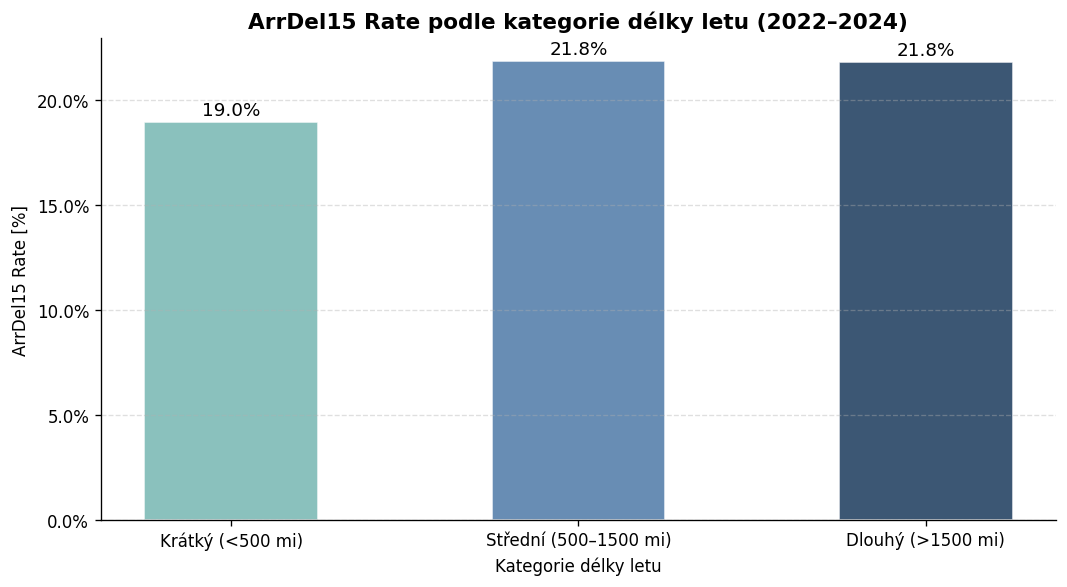

In [141]:
# BQ2 – Viz 1: ArrDel15 Rate dle kategorie délky letu
fig, ax = plt.subplots(figsize=(9, 5))
colors_dist = ["#76b7b2", "#4e79a7", "#1a3a5c"]
bars = ax.bar(bq2["DistanceCat"].astype(str), bq2["ArrDel15Rate"],
              color=colors_dist, alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars, bq2["ArrDel15Rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("ArrDel15 Rate podle kategorie délky letu (2022–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("ArrDel15 Rate [%]")
ax.set_xlabel("Kategorie délky letu")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq2_viz1_arrDel15_by_distance.png"), dpi=150, bbox_inches="tight")
plt.show()


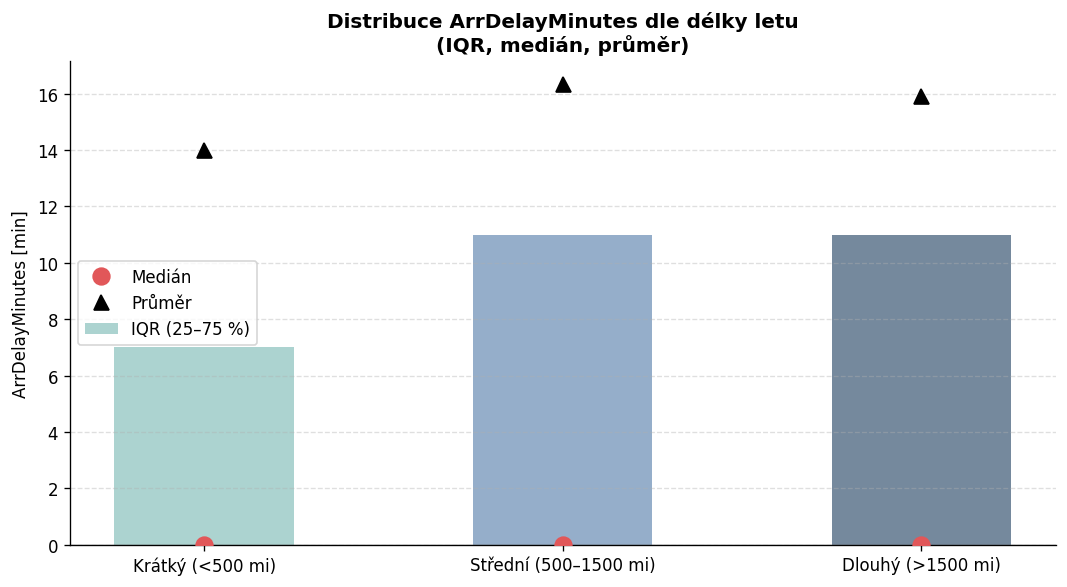

In [142]:
# BQ2 – Viz 2: Distribuce zpoždění dle délky letu (IQR + průměr + medián)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bq2_dist))
ax.bar(x,
       bq2_dist["75%"] - bq2_dist["25%"],
       bottom=bq2_dist["25%"],
       color=colors_dist, alpha=0.6, width=0.5, label="IQR (25–75 %)")
ax.plot(x, bq2_dist["50%"], "o", color="#e15759",
        markersize=10, label="Medián", zorder=5)
ax.plot(x, bq2_dist["mean"], "^", color="black",
        markersize=9, label="Průměr", zorder=5)
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in bq2_dist["DistanceCat"]])
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Distribuce ArrDelayMinutes dle délky letu\n(IQR, medián, průměr)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("ArrDelayMinutes [min]")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq2_viz2_distribution_by_distance.png"), dpi=150, bbox_inches="tight")
plt.show()


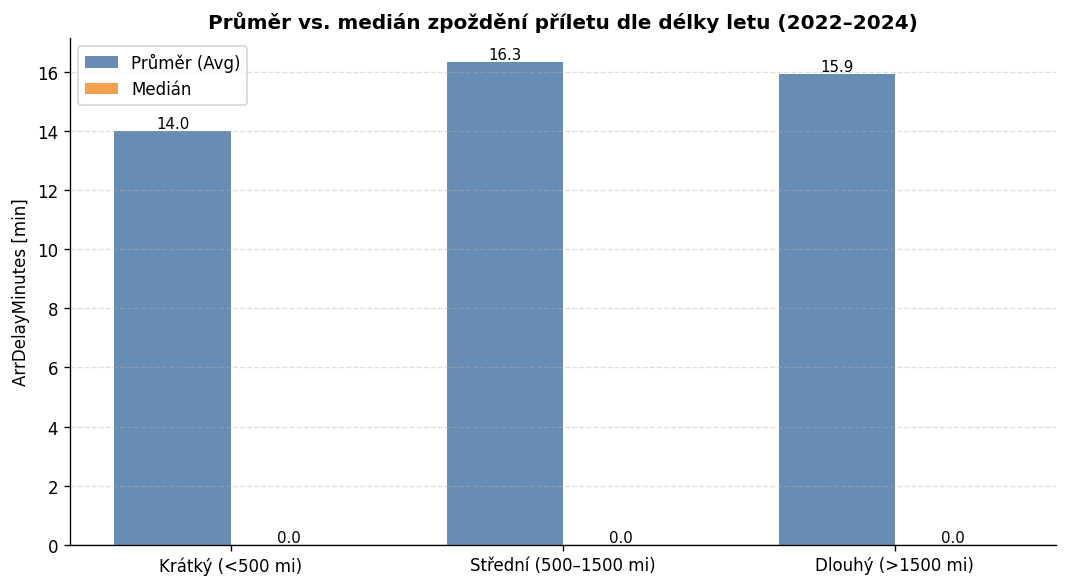

In [143]:
# BQ2 – Viz 3: Průměr vs. medián zpoždění příletu dle délky letu (grouped bar)
x = np.arange(len(bq2))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, bq2["AvgArrDelay"], width,
            label="Průměr (Avg)", color="#4e79a7", alpha=0.85)
b2 = ax.bar(x + width/2, bq2["MedianArrDelay"], width,
            label="Medián", color="#f28e2b", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in bq2["DistanceCat"]])
ax.set_title("Průměr vs. medián zpoždění příletu dle délky letu (2022–2024)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("ArrDelayMinutes [min]")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
for b, v in zip(b1, bq2["AvgArrDelay"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{v:.1f}", ha="center", fontsize=9)
for b, v in zip(b2, bq2["MedianArrDelay"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{v:.1f}", ha="center", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq2_viz3_avg_vs_median_by_distance.png"), dpi=150, bbox_inches="tight")
plt.show()


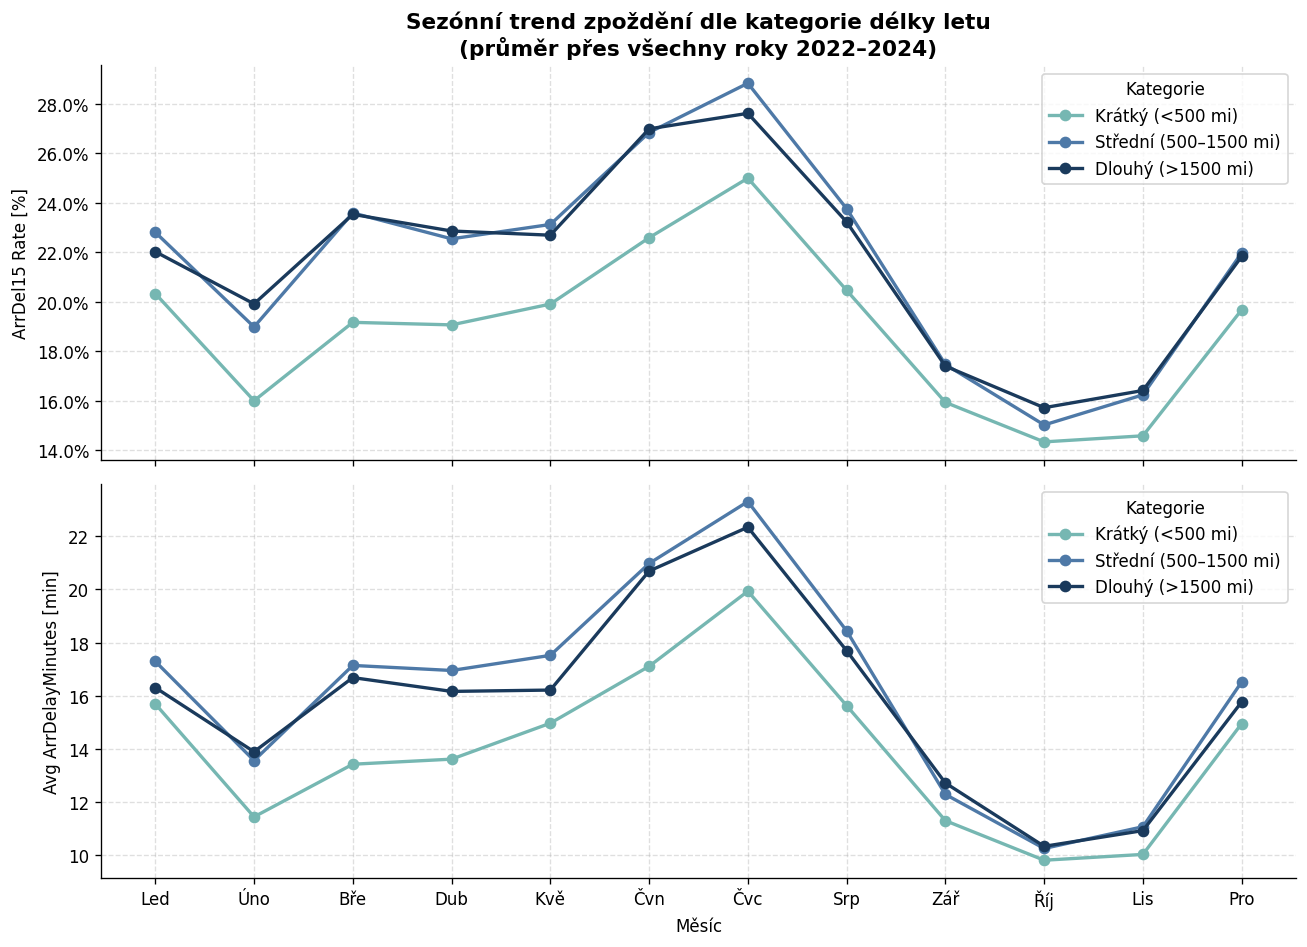

In [144]:
# BQ2 – Viz 4: Sezónní trend zpoždění dle kategorie délky letu (průměr přes 2022–2024)
colors_cat = {
    "Krátký (<500 mi)":       "#76b7b2",
    "Střední (500–1500 mi)":  "#4e79a7",
    "Dlouhý (>1500 mi)":      "#1a3a5c"
}

_f = os.path.join(DATA_DIR, "bq2_seasonal.csv")
if os.path.exists(_f):
    bq2_seasonal = pd.read_csv(_f)
else:
    bq2_seasonal = (
        df_ops.dropna(subset=["DistanceCat"])
        .groupby(["Month", "DistanceCat"], observed=True)
        .agg(
            ArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100),
            AvgArrDelay=("ArrDelayMinutes", "mean")
        )
        .reset_index()
        .sort_values("Month")
    )
    bq2_seasonal.to_csv(_f, index=False)

month_labels = [MONTH_NAMES[m] for m in range(1, 13)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for cat, grp in bq2_seasonal.groupby("DistanceCat", observed=True):
    grp_s = grp.sort_values("Month")
    ax1.plot(grp_s["Month"], grp_s["ArrDel15Rate"], marker="o", linewidth=2,
             label=str(cat), color=colors_cat[str(cat)])
    ax2.plot(grp_s["Month"], grp_s["AvgArrDelay"], marker="o", linewidth=2,
             label=str(cat), color=colors_cat[str(cat)])

for ax in (ax1, ax2):
    ax.set_xticks(range(1, 13))
    ax.grid(linestyle="--", alpha=0.4)

ax2.set_xticklabels(month_labels)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylabel("ArrDel15 Rate [%]")
ax1.set_title("Sezónní trend zpoždění dle kategorie délky letu\n(průměr přes všechny roky 2022–2024)",
              fontsize=13, fontweight="bold")
ax1.legend(title="Kategorie")
ax2.set_ylabel("Avg ArrDelayMinutes [min]")
ax2.set_xlabel("Měsíc")
ax2.legend(title="Kategorie")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq2_viz4_seasonal_by_distance.png"), dpi=150, bbox_inches="tight")
plt.show()


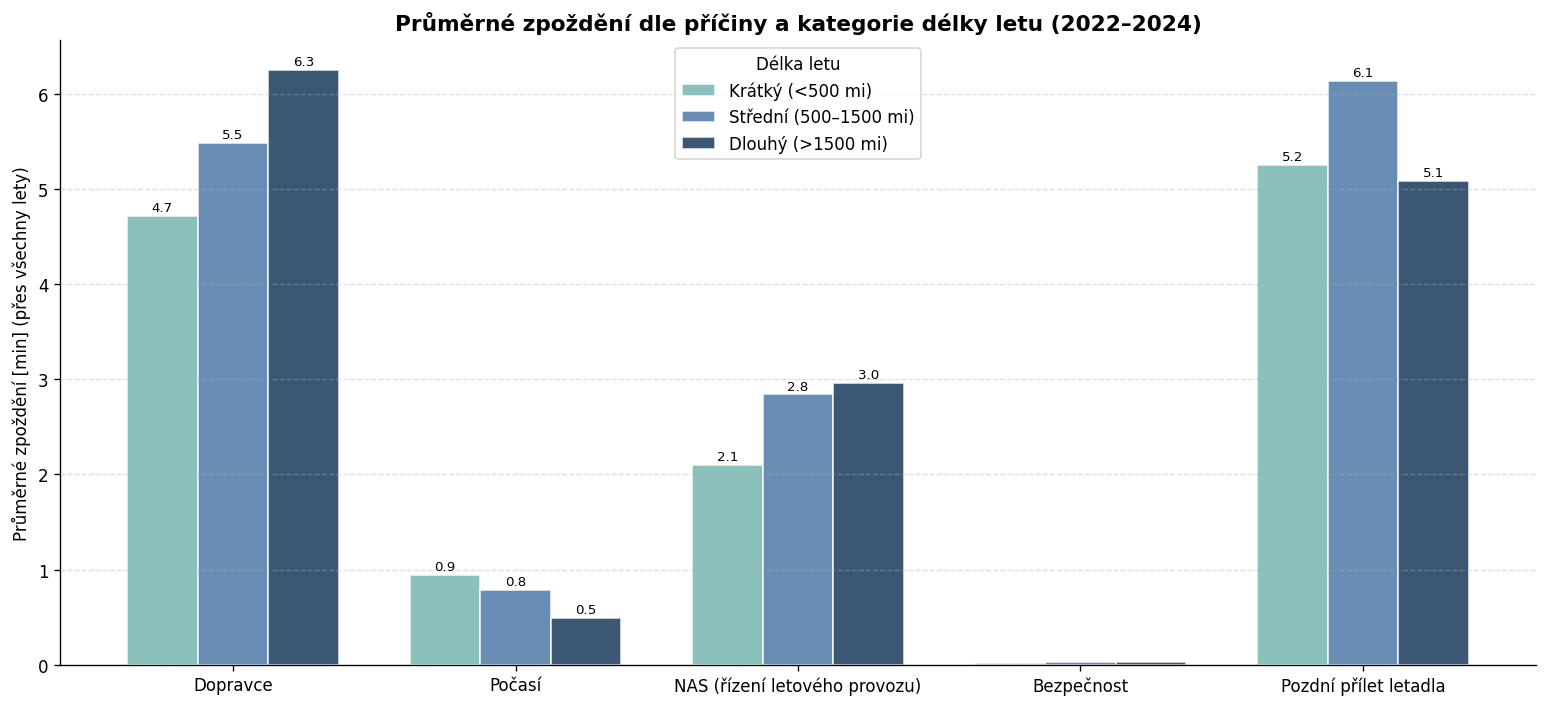

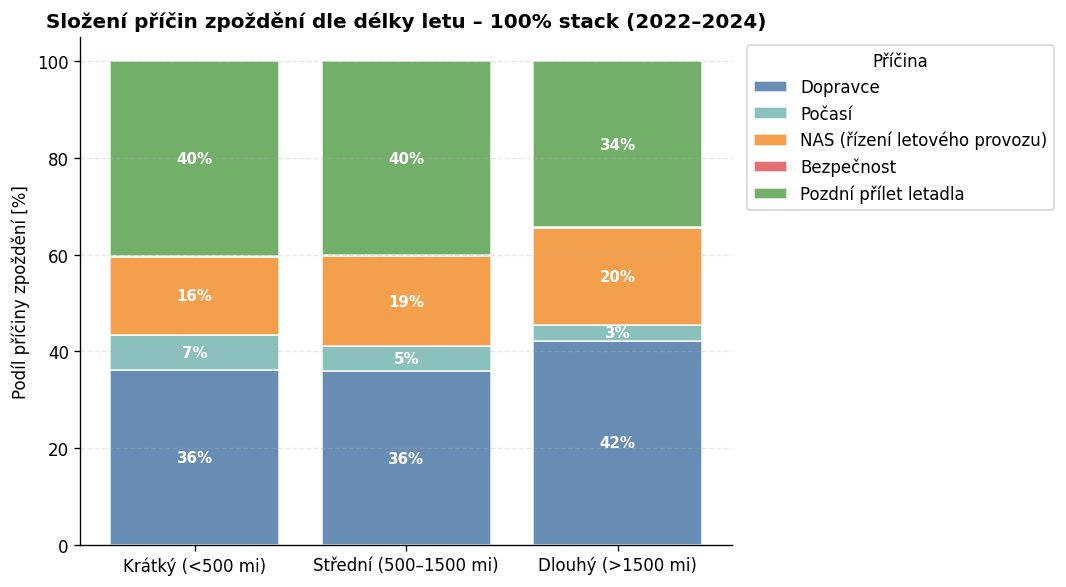

In [145]:
# BQ2 – Viz 5: Průměrné zpoždění dle typu příčiny a kategorie délky letu
DELAY_TYPES = {
    "CarrierDelay":      "Dopravce",
    "WeatherDelay":      "Počasí",
    "NASDelay":          "NAS (řízení letového provozu)",
    "SecurityDelay":     "Bezpečnost",
    "LateAircraftDelay": "Pozdní přílet letadla"
}
dist_cats    = ["Krátký (<500 mi)", "Střední (500–1500 mi)", "Dlouhý (>1500 mi)"]
delay_labels = list(DELAY_TYPES.values())
colors_types = ["#4e79a7", "#76b7b2", "#f28e2b", "#e15759", "#59a14f"]

_f = os.path.join(DATA_DIR, "bq2_types.csv")
if os.path.exists(_f):
    bq2_types = pd.read_csv(_f)
else:
    df_delay = df_ops.dropna(subset=["DistanceCat"]).copy()
    for col in DELAY_TYPES:
        df_delay[col] = df_delay[col].fillna(0)
    bq2_types = (
        df_delay.groupby("DistanceCat", observed=True)[list(DELAY_TYPES.keys())]
        .mean()
        .reset_index()
        .melt(id_vars="DistanceCat", var_name="DelayType", value_name="AvgMinutes")
    )
    bq2_types["DelayTypeLabel"] = bq2_types["DelayType"].map(DELAY_TYPES)
    bq2_types.to_csv(_f, index=False)

# Grouped bar chart
x = np.arange(len(delay_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, cat in enumerate(dist_cats):
    vals = [
        bq2_types.loc[(bq2_types["DistanceCat"] == cat) &
                      (bq2_types["DelayTypeLabel"] == dl), "AvgMinutes"].values[0]
        for dl in delay_labels
    ]
    bars = ax.bar(x + i * width, vals, width, label=cat,
                  color=colors_cat[cat], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        if v > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(delay_labels, fontsize=10)
ax.set_ylabel("Průměrné zpoždění [min] (přes všechny lety)")
ax.set_title("Průměrné zpoždění dle příčiny a kategorie délky letu (2022–2024)",
             fontsize=13, fontweight="bold")
ax.legend(title="Délka letu")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq2_viz5a_delay_by_type.png"), dpi=150, bbox_inches="tight")
plt.show()

# Podíl jednotlivých příčin (stacked 100%)
bq2_pct = bq2_types.copy()
totals = bq2_pct.groupby("DistanceCat")["AvgMinutes"].transform("sum")
bq2_pct["Pct"] = bq2_pct["AvgMinutes"] / totals * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(dist_cats))
for j, (col, label) in enumerate(DELAY_TYPES.items()):
    vals = [bq2_pct.loc[(bq2_pct["DistanceCat"]==c) &
                        (bq2_pct["DelayTypeLabel"]==label), "Pct"].values[0]
            for c in dist_cats]
    bars = ax.bar(dist_cats, vals, bottom=bottom, label=label,
                  color=colors_types[j], alpha=0.85, edgecolor="white")
    for bar, v, b in zip(bars, vals, bottom):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f"{v:.0f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottom += np.array(vals)

ax.set_ylabel("Podíl příčiny zpoždění [%]")
ax.set_title("Složení příčin zpoždění dle délky letu – 100% stack (2022–2024)",
             fontsize=12, fontweight="bold")
ax.legend(title="Příčina", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq2_viz5b_composition_100pct.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## BQ3 – Odlet vs. přílet: schopnost kompenzace zpoždění

**Business otázka:** Jaký je v období 2022–2024 vztah mezi zpožděním odletu a zpožděním příletu a do jaké míry jsou dopravci schopni zpoždění během letu kompenzovat?

**Hypotéza:** Část zpoždění vzniklého při odletu může být během letu kompenzována (rychlejší trasa, zkrácení trasy, tailwind). Různí dopravci mohou mít různou schopnost kompenzace.

**KPI:**
- `Avg DepDelayMinutes` = průměrné zpoždění odletu
- `Avg ArrDelayMinutes` = průměrné zpoždění příletu
- `Avg DelayDiff` = ArrDelayMinutes − DepDelayMinutes (záporné = dopravce dohnal zpoždění)

**Poznámka k metadatům:**
- `DepDelayMinutes` a `ArrDelayMinutes` jsou **předpočítané metriky s dolním limitem 0** — brzy odlétající/přilétající lety mají hodnotu 0, nikoliv zápornou. Záporné hodnoty existují pouze v `DepDelay` / `ArrDelay` (bez "Minutes"), které zde nepoužíváme.
- `DelayDiff = ArrDelayMinutes − DepDelayMinutes` může být záporný: např. DepDelayMinutes=20, ArrDelayMinutes=8 → DelayDiff=−12 = dopravce kompenzoval 12 minut.
- Analýza je omezena na **Top 10 dopravců** dle počtu letů pro přehlednost scatter plotu.
- Scatter plot: bod nad diagonálou (ArrDelay > DepDelay) = zpoždění se zhoršilo; pod diagonálou = kompenzace.

In [146]:
# --- BQ3: Výpočet KPI dle dopravce (Top 10) ---
df_top10 = df_ops[df_ops["Reporting_Airline"].isin(TOP10)]

bq3 = df_top10.groupby("Reporting_Airline").agg(
    TotalFlights=("DelayDiff", "count"),
    AvgDepDelay=("DepDelayMinutes", "mean"),
    AvgArrDelay=("ArrDelayMinutes", "mean"),
    AvgDelayDiff=("DelayDiff", "mean"),
    MedianDelayDiff=("DelayDiff", "median")
).reset_index().sort_values("AvgDelayDiff")

print("KPI dle dopravce – odlet vs. přílet (Top 10, 2022–2024):")
print(bq3.to_string(index=False, float_format="{:.2f}".format))
print("\nInterpretace Avg DelayDiff:")
print("  záporná hodnota → dopravce průměrně kompenzoval zpoždění (arr < dep)")
print("  kladná hodnota  → zpoždění se průměrně zhoršilo (arr > dep)")

bq3.to_csv(os.path.join(DATA_DIR, "bq3.csv"), index=False)
print(f"\n✓ Uloženo: {DATA_DIR}/bq3.csv")


KPI dle dopravce – odlet vs. přílet (Top 10, 2022–2024):
Reporting_Airline  TotalFlights  AvgDepDelay  AvgArrDelay  AvgDelayDiff  MedianDelayDiff
               WN       4087700        14.16        12.65         -1.51             0.00
               DL       2847949        13.03        12.65         -0.38             0.00
               B6        765460        25.21        25.00         -0.21             0.00
               UA       2078839        15.43        15.24         -0.19             0.00
               NK        739503        19.27        19.16         -0.11             0.00
               AA       2740111        20.69        20.91          0.22             0.00
               OO       2116996        14.20        14.78          0.58             0.00
               AS        704457        10.89        11.74          0.84             0.00
               MQ        741951        11.50        12.70          1.21             0.00
               YX        882646         9.96        1

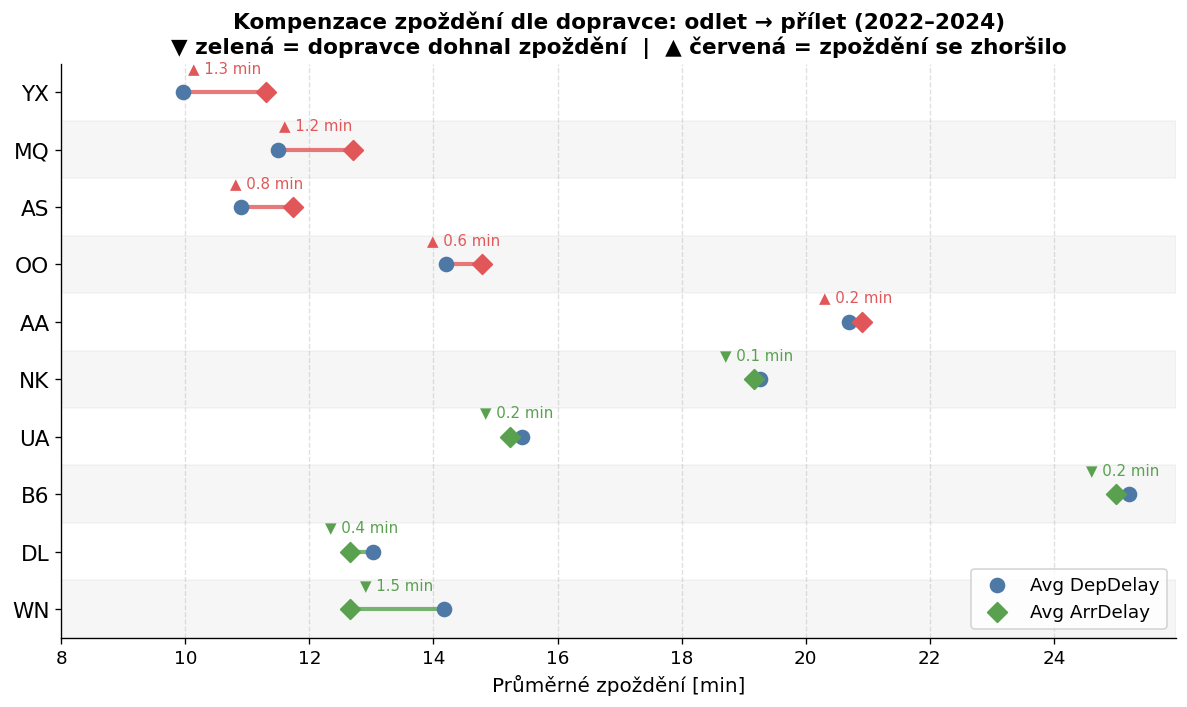

In [147]:
# BQ3 – Viz 1: Dumbbell chart – DepDelay vs. ArrDelay dle dopravce
bq3_sorted = bq3.sort_values("AvgDelayDiff", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(bq3_sorted))

# Střídavé stínování řádků pro snadnější čtení
for i in range(len(bq3_sorted)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color="gray", alpha=0.07, zorder=0)

for i, (_, row) in enumerate(bq3_sorted.iterrows()):
    color = "#59a14f" if row["AvgDelayDiff"] < 0 else "#e15759"
    ax.plot([row["AvgDepDelay"], row["AvgArrDelay"]], [i, i],
            color=color, linewidth=2.5, alpha=0.8, zorder=2)
    ax.scatter(row["AvgDepDelay"], i, color="#4e79a7", s=70,
               zorder=3, label="Avg DepDelay" if i == 0 else "")
    ax.scatter(row["AvgArrDelay"], i, color="#e15759" if row["AvgDelayDiff"] >= 0 else "#59a14f",
               s=70, zorder=3, marker="D",
               label="Avg ArrDelay" if i == 0 else "")
    mid = (row["AvgDepDelay"] + row["AvgArrDelay"]) / 2
    sign = "▼" if row["AvgDelayDiff"] < 0 else "▲"
    ax.text(mid, i + 0.3, f"{sign} {abs(row['AvgDelayDiff']):.1f} min",
            ha="center", va="bottom", fontsize=9,
            color="#59a14f" if row["AvgDelayDiff"] < 0 else "#e15759")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(bq3_sorted["Reporting_Airline"], fontsize=13)
ax.set_xlabel("Průměrné zpoždění [min]", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.set_xlim(left=8)
ax.set_ylim(-0.5, len(bq3_sorted) - 0.5)
ax.set_title("Kompenzace zpoždění dle dopravce: odlet → přílet (2022–2024)\n"
             "▼ zelená = dopravce dohnal zpoždění  |  ▲ červená = zpoždění se zhoršilo",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq3_viz1_dumbbell_top10.png"), dpi=150, bbox_inches="tight")
plt.show()


Celkem dopravců v datech: 17
Reporting_Airline  TotalFlights  AvgDepDelay  AvgArrDelay  AvgDelayDiff  ArrDel15Rate
               WN       4087700        14.16        12.65         -1.51         22.13
               DL       2847949        13.03        12.65         -0.38         16.56
               AA       2740111        20.69        20.91          0.22         23.98
               OO       2116996        14.20        14.78          0.58         17.34
               UA       2078839        15.43        15.24         -0.19         19.94
               YX        882646         9.96        11.30          1.35         15.63
               B6        765460        25.21        25.00         -0.21         29.92
               MQ        741951        11.50        12.70          1.21         18.88
               NK        739503        19.27        19.16         -0.11         25.97
               AS        704457        10.89        11.74          0.84         20.68
               OH        

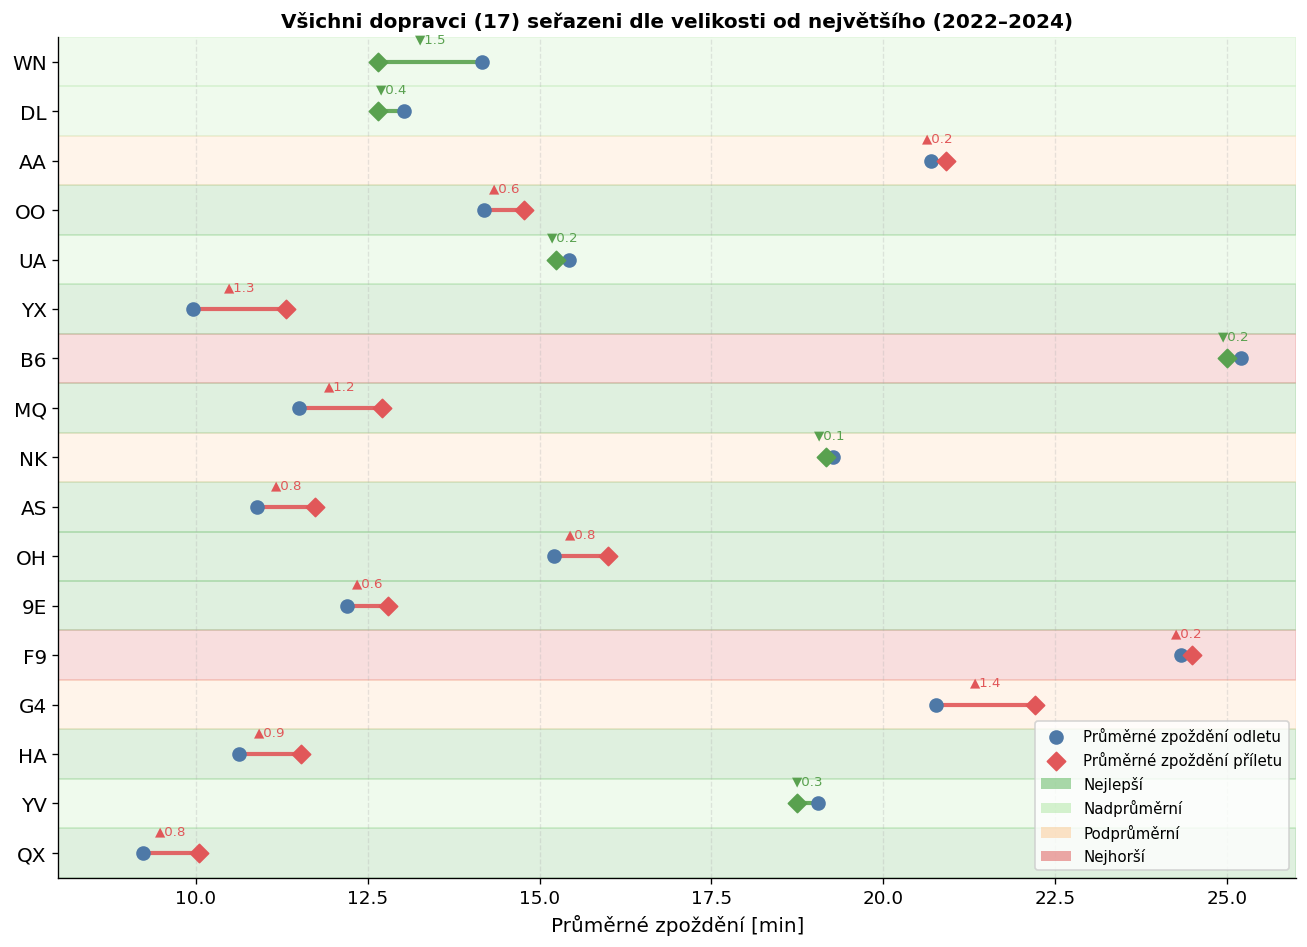

In [148]:
# BQ3 – Viz 1b: Všichni dopravci (17) seskupeni do výkonnostních tierů (KMeans)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

tier_labels = {1: "Nejlepší", 2: "Nadprůměrní", 3: "Podprůměrní", 4: "Nejhorší"}
tier_colors = {1: "#2ca02c", 2: "#98df8a", 3: "#ffbb78", 4: "#d62728"}

_f = os.path.join(DATA_DIR, "bq3_all.csv")
if os.path.exists(_f):
    bq3_all = pd.read_csv(_f)
    bq3_all["Tier"] = bq3_all["Tier"].astype(int)
    print(f"Celkem dopravců v datech: {len(bq3_all)}")
    print(bq3_all.sort_values("TotalFlights", ascending=False)
          [["Reporting_Airline","TotalFlights","AvgDepDelay","AvgArrDelay","AvgDelayDiff","ArrDel15Rate"]]
          .to_string(index=False, float_format="{:.2f}".format))
else:
    bq3_all = df_ops.groupby("Reporting_Airline").agg(
        TotalFlights=("DelayDiff", "count"),
        AvgDepDelay=("DepDelayMinutes", "mean"),
        AvgArrDelay=("ArrDelayMinutes", "mean"),
        AvgDelayDiff=("DelayDiff", "mean"),
        ArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100)
    ).reset_index()

    print(f"Celkem dopravců v datech: {len(bq3_all)}")
    print(bq3_all.sort_values("TotalFlights", ascending=False)
          [["Reporting_Airline","TotalFlights","AvgDepDelay","AvgArrDelay","AvgDelayDiff","ArrDel15Rate"]]
          .to_string(index=False, float_format="{:.2f}".format))

    features = ["AvgDepDelay", "AvgArrDelay", "AvgDelayDiff", "ArrDel15Rate"]
    X = StandardScaler().fit_transform(bq3_all[features])
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    bq3_all["Cluster"] = kmeans.fit_predict(X)
    tier_order = bq3_all.groupby("Cluster")["ArrDel15Rate"].mean().sort_values()
    tier_map = {old: new for new, old in enumerate(tier_order.index, 1)}
    bq3_all["Tier"] = bq3_all["Cluster"].map(tier_map)
    bq3_all["TierLabel"] = bq3_all["Tier"].map(tier_labels)
    bq3_all.to_csv(_f, index=False)

print("\nRozdělení do tierů:")
print(bq3_all[["Reporting_Airline","Tier","TierLabel","ArrDel15Rate","AvgDelayDiff"]]
      .sort_values(["Tier","ArrDel15Rate"]).to_string(index=False, float_format="{:.2f}".format))

bq3_all_sorted = bq3_all.sort_values("TotalFlights", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
for i, (_, row) in enumerate(bq3_all_sorted.iterrows()):
    tc = tier_colors[row["Tier"]]
    line_color = "#59a14f" if row["AvgDelayDiff"] < 0 else "#e15759"
    ax.axhspan(i - 0.5, i + 0.5, color=tc, alpha=0.15, zorder=0)
    ax.plot([row["AvgDepDelay"], row["AvgArrDelay"]], [i, i],
            color=line_color, linewidth=2.5, alpha=0.9, zorder=2)
    ax.scatter(row["AvgDepDelay"], i, color="#4e79a7", s=60, zorder=3,
               label="Avg DepDelay" if i == 0 else "")
    ax.scatter(row["AvgArrDelay"], i, color=line_color, s=60, zorder=3, marker="D",
               label="Avg ArrDelay" if i == 0 else "")
    sign = "▼" if row["AvgDelayDiff"] < 0 else "▲"
    mid = (row["AvgDepDelay"] + row["AvgArrDelay"]) / 2
    ax.text(mid, i + 0.32, f"{sign}{abs(row['AvgDelayDiff']):.1f}",
            ha="center", va="bottom", fontsize=8, color=line_color)

ax.set_yticks(range(len(bq3_all_sorted)))
ax.set_yticklabels(bq3_all_sorted["Reporting_Airline"], fontsize=12)
ax.set_xlim(left=8)
ax.set_ylim(-0.5, len(bq3_all_sorted) - 0.5)
ax.set_xlabel("Průměrné zpoždění [min]", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.set_title("Všichni dopravci (17) seřazeni dle velikosti od největšího (2022–2024)",
             fontsize=12, fontweight="bold")

from matplotlib.patches import Patch as _P
ax.legend(
    handles=[ax.get_legend_handles_labels()[0][0], ax.get_legend_handles_labels()[0][1]] +
            [_P(facecolor=tier_colors[t], alpha=0.4, label=tier_labels[t]) for t in range(1, 5)],
    labels=["Průměrné zpoždění odletu", "Průměrné zpoždění příletu"] + [tier_labels[t] for t in range(1, 5)],
    loc="lower right", fontsize=9
)
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq3_viz1b_all_carriers_tiered.png"), dpi=150, bbox_inches="tight")
plt.show()


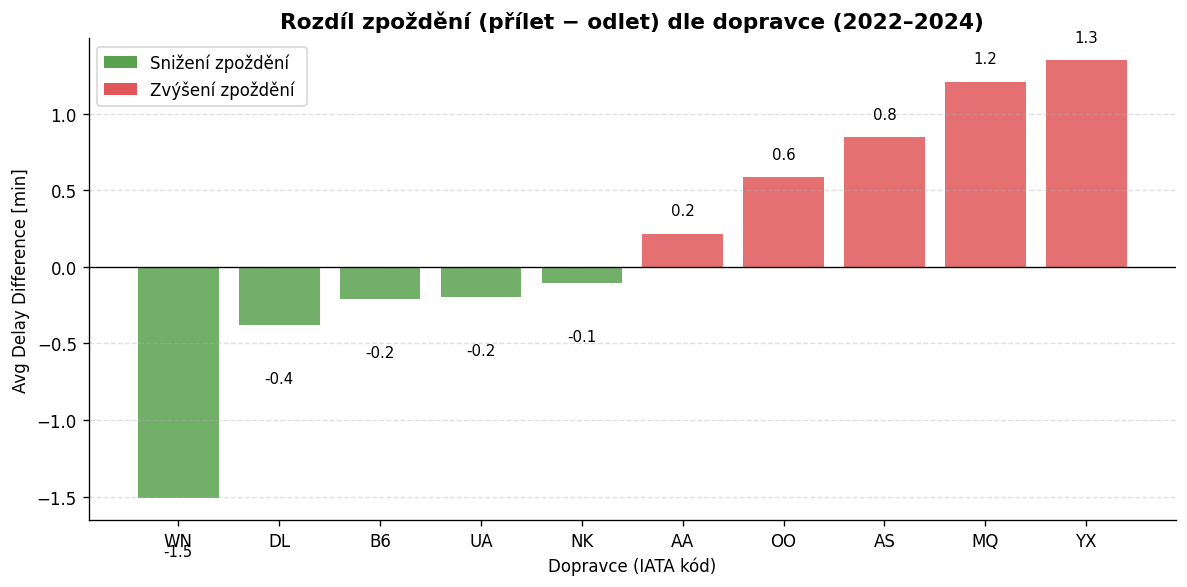

In [149]:
# BQ3 – Viz 2: Sloupcový graf – rozdíl zpoždění dle dopravce (Avg DelayDiff)
from matplotlib.patches import Patch as _Patch
fig, ax = plt.subplots(figsize=(10, 5))
colors_dd = ["#59a14f" if v < 0 else "#e15759" for v in bq3["AvgDelayDiff"]]
bars = ax.bar(bq3["Reporting_Airline"], bq3["AvgDelayDiff"],
              color=colors_dd, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, bq3["AvgDelayDiff"]):
    offset = 0.1 if val >= 0 else -0.3
    va = "bottom" if val >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset, f"{val:.1f}",
            ha="center", va=va, fontsize=9)
ax.set_title("Rozdíl zpoždění (přílet − odlet) dle dopravce (2022–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Delay Difference [min]")
ax.set_xlabel("Dopravce (IATA kód)")
ax.legend(handles=[
    _Patch(facecolor="#59a14f", label="Snižení zpoždění "),
    _Patch(facecolor="#e15759", label="Zvýšení zpoždění ")
])
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq3_viz2_delay_diff_by_carrier.png"), dpi=150, bbox_inches="tight")
plt.show()


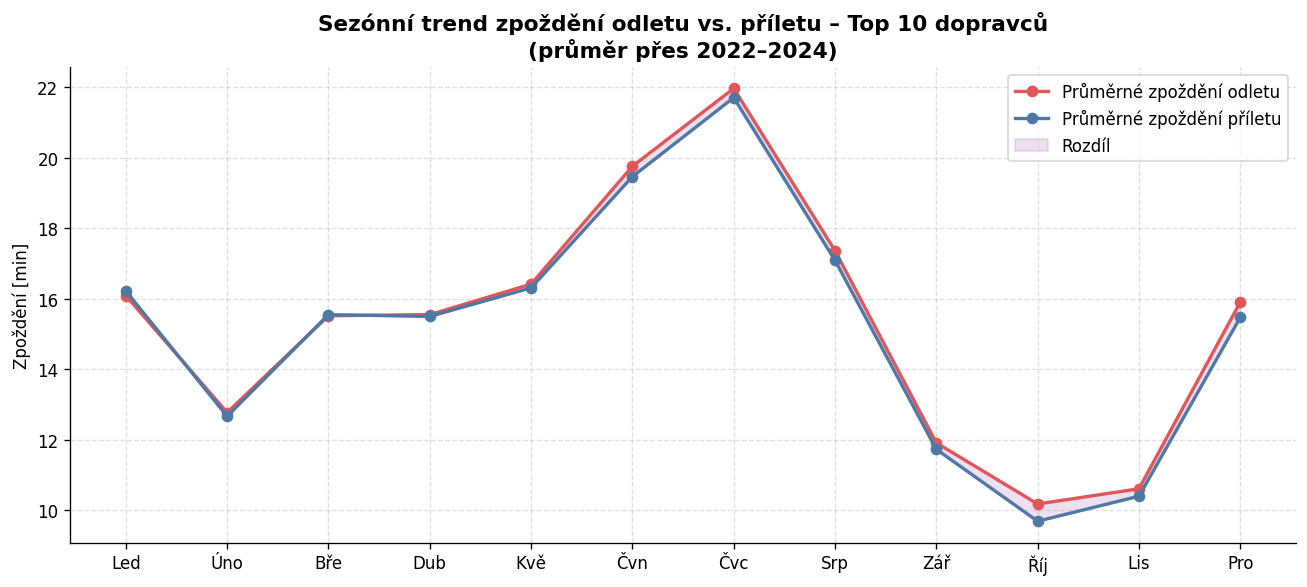

In [150]:
# BQ3 – Viz 3: Sezónní trend zpoždění odletu vs. příletu (průměr přes 2022–2024)
_f = os.path.join(DATA_DIR, "bq3_seasonal.csv")
if os.path.exists(_f):
    bq3_seasonal = pd.read_csv(_f)
else:
    bq3_seasonal = df_top10.groupby("Month").agg(
        AvgDepDelay=("DepDelayMinutes", "mean"),
        AvgArrDelay=("ArrDelayMinutes", "mean")
    ).reset_index().sort_values("Month")
    bq3_seasonal.to_csv(_f, index=False)

month_labels = [MONTH_NAMES[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bq3_seasonal["Month"], bq3_seasonal["AvgDepDelay"],
        marker="o", label="Průměrné zpoždění odletu", color="#e15759", linewidth=2)
ax.plot(bq3_seasonal["Month"], bq3_seasonal["AvgArrDelay"],
        marker="o", label="Průměrné zpoždění příletu", color="#4e79a7", linewidth=2)
ax.fill_between(bq3_seasonal["Month"],
                bq3_seasonal["AvgDepDelay"], bq3_seasonal["AvgArrDelay"],
                alpha=0.12, color="purple", label="Rozdíl")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Sezónní trend zpoždění odletu vs. příletu – Top 10 dopravců\n(průměr přes 2022–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Zpoždění [min]")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq3_viz3_seasonal_dep_vs_arr.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## BQ4 – Stabilita výkonu dopravců v čase

**Business otázka:** Jak stabilní je výkon jednotlivých dopravců v čase (2022–2024) a dochází k výrazným výkyvům ve spolehlivosti mezi měsíci?

**Hypotéza:** Někteří dopravci vykazují stabilní výkon bez výrazných výkyvů (nízká směrodatná odchylka), zatímco jiní jsou citlivější na sezónnost nebo provozní špičky.

**KPI:**
- `ArrDel15 Rate` = měsíční frekvence problému
- `Avg ArrDelayMinutes` = měsíční průměrné zpoždění (intenzita)
- `StdDev ArrDelayMinutes` = směrodatná odchylka přes všechna lety = míra nestability / volatility
- `Rolling 3M Avg` = klouzavý 3měsíční průměr (vyhlazení šumu, odhalení trendu)

**Poznámka k metadatům:** Směrodatná odchylka je počítána přes jednotlivé záznamy letů (ne přes měsíční průměry), což lépe odráží variabilitu provozní spolehlivosti. Rolling average je počítána přes měsíční KPI hodnoty.

In [151]:
# --- BQ4: Výpočet KPI dle dopravce a měsíce (Top 10 pro line chart) ---
bq4_monthly = df_top10.groupby(["YearMonth", "Reporting_Airline"]).agg(
    ArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100),
    AvgArrDelay=("ArrDelayMinutes", "mean"),
    TotalFlights=("ArrDel15", "count")
).reset_index().sort_values(["Reporting_Airline", "YearMonth"])

# Souhrnné statistiky – TOP 10 (pro line chart a rolling trend)
bq4_summary = df_top10.groupby("Reporting_Airline").agg(
    AvgArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100),
    AvgArrDelay=("ArrDelayMinutes", "mean"),
    StdArrDelay=("ArrDelayMinutes", "std"),
    TotalFlights=("ArrDel15", "count")
).reset_index().sort_values("AvgArrDel15Rate")

# Souhrnné statistiky – VŠECH 17 dopravců (pro scatter)
bq4_summary_all = df_ops.groupby("Reporting_Airline").agg(
    AvgArrDel15Rate=("ArrDel15", lambda x: x.mean() * 100),
    AvgArrDelay=("ArrDelayMinutes", "mean"),
    StdArrDelay=("ArrDelayMinutes", "std"),
    TotalFlights=("ArrDel15", "count")
).reset_index().sort_values("AvgArrDel15Rate")

print("Souhrnná stabilita – Top 10 (2022–2024):")
print(bq4_summary.to_string(index=False, float_format="{:.2f}".format))
print(f"\nCelkem dopravců (všichni): {len(bq4_summary_all)}")
print("Nižší StdArrDelay = stabilnější provoz")

bq4_monthly.to_csv(os.path.join(DATA_DIR, "bq4_monthly.csv"), index=False)
bq4_summary_all.to_csv(os.path.join(DATA_DIR, "bq4_summary_all.csv"), index=False)
print(f"\n✓ Uloženo: {DATA_DIR}/bq4_monthly.csv, bq4_summary_all.csv")


Souhrnná stabilita – Top 10 (2022–2024):
Reporting_Airline  AvgArrDel15Rate  AvgArrDelay  StdArrDelay  TotalFlights
               YX            15.63        11.30        41.31        882646
               DL            16.56        12.65        48.61       2847949
               OO            17.34        14.78        58.89       2116996
               MQ            18.88        12.70        41.59        741951
               UA            19.94        15.24        50.05       2078839
               AS            20.68        11.74        31.42        704457
               WN            22.13        12.65        30.97       4087700
               AA            23.98        20.91        77.06       2740111
               NK            25.97        19.16        50.75        739503
               B6            29.92        25.00        65.16        765460

Celkem dopravců (všichni): 17
Nižší StdArrDelay = stabilnější provoz

✓ Uloženo: data/bq4_monthly.csv, bq4_summary_all.csv


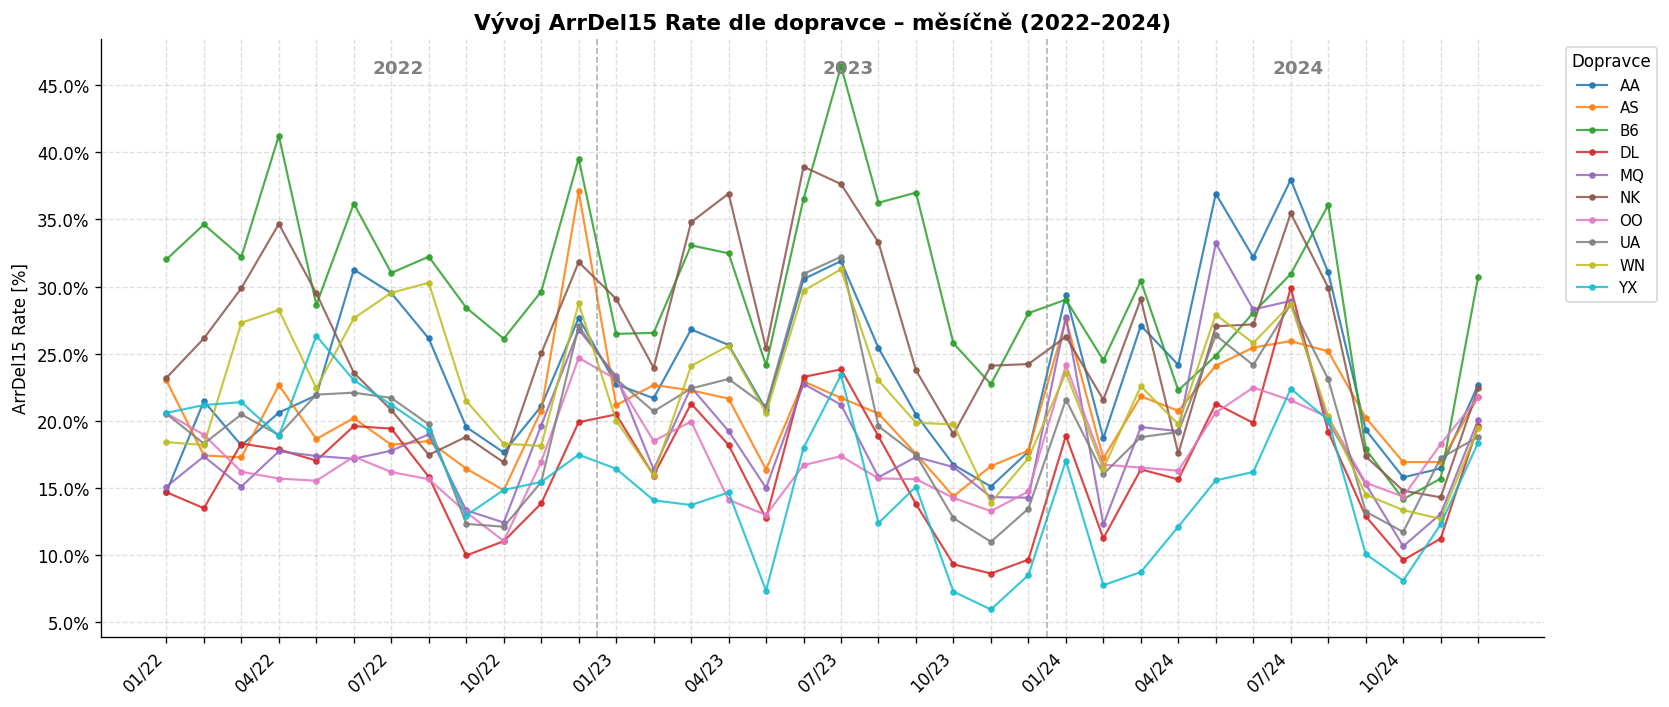

In [152]:
# BQ4 – Viz 1: Vývoj ArrDel15 Rate dle dopravce (měsíčně, line chart)
ym_vals = sorted(bq4_monthly["YearMonth"].unique())
ym_index = {v: i for i, v in enumerate(ym_vals)}

fig, ax = plt.subplots(figsize=(14, 6))
for carrier, grp in bq4_monthly.groupby("Reporting_Airline"):
    grp_s = grp.sort_values("YearMonth")
    xs = [ym_index[v] for v in grp_s["YearMonth"]]
    ax.plot(xs, grp_s["ArrDel15Rate"],
            marker=".", linewidth=1.3, label=carrier, alpha=0.85)

# Oddělení roků
year_boundaries = {2022: 0, 2023: 12, 2024: 24}
y_top = ax.get_ylim()[1]
for year, x_start in year_boundaries.items():
    if x_start > 0:
        ax.axvline(x=x_start - 0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(x_start + 5.5, y_top * 0.97, str(year),
            fontsize=11, color="gray", fontweight="bold", va="top")

ax.set_xticks(range(len(ym_vals)))
ax.set_xticklabels(
    [MONTH_LABELS.get(v, str(v)) if i % 3 == 0 else "" for i, v in enumerate(ym_vals)],
    rotation=45, ha="right"
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Vývoj ArrDel15 Rate dle dopravce – měsíčně (2022–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("ArrDel15 Rate [%]")
ax.legend(title="Dopravce", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq4_viz1_monthly_by_carrier.png"), dpi=150, bbox_inches="tight")
plt.show()


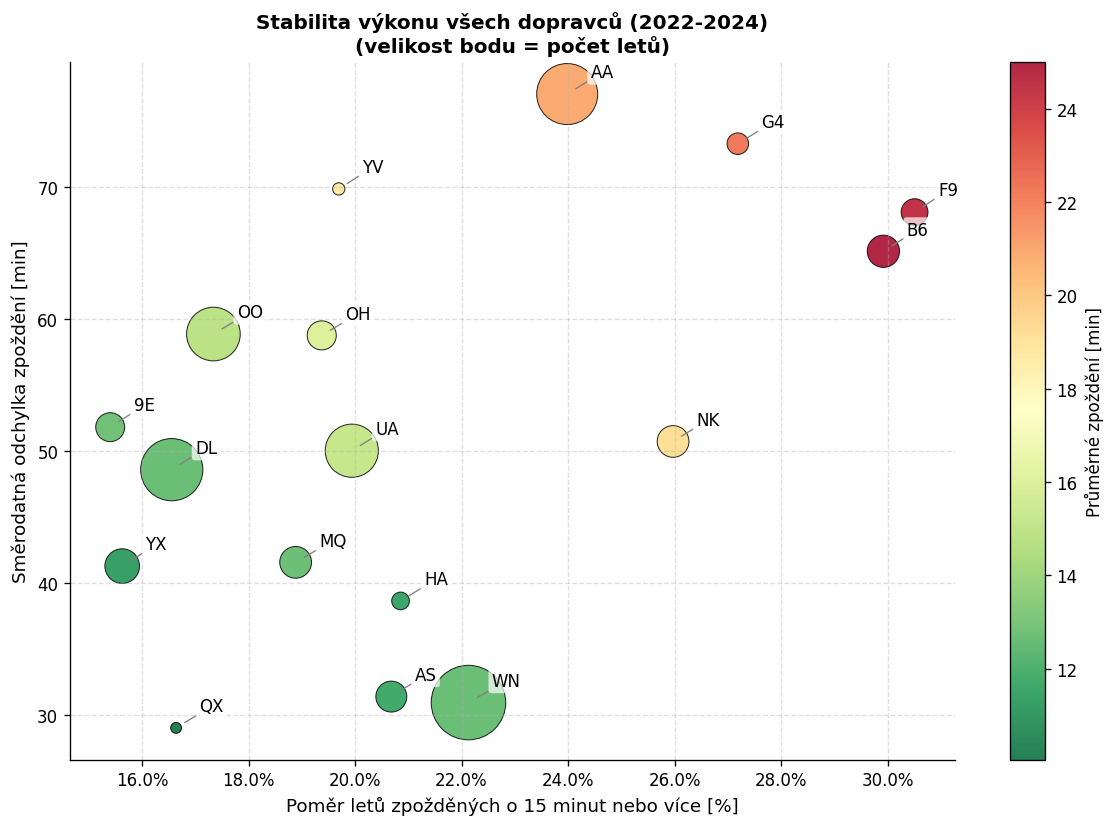

In [153]:
# BQ4 – Viz 2: Scatter – výkon vs. stabilita (všech 17 dopravců)
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    bq4_summary_all["AvgArrDel15Rate"], bq4_summary_all["StdArrDelay"],
    s=bq4_summary_all["TotalFlights"] / bq4_summary_all["TotalFlights"].max() * 2000,
    c=bq4_summary_all["AvgArrDelay"], cmap="RdYlGn_r",
    alpha=0.85, edgecolors="black", linewidth=0.6
)
plt.colorbar(scatter, ax=ax, label="Průměrné zpoždění [min]")
ax.set_xlabel("Poměr letů zpožděných o 15 minut nebo více [%]", fontsize=11)
ax.set_ylabel("Směrodatná odchylka zpoždění [min]", fontsize=11)
ax.set_title("Stabilita výkonu všech dopravců (2022-2024)\n"
             "(velikost bodu = počet letů)",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(linestyle="--", alpha=0.4)

# Popisky s šipkou
for _, row in bq4_summary_all.iterrows():
    ax.annotate(
        row["Reporting_Airline"],
        xy=(row["AvgArrDel15Rate"], row["StdArrDelay"]),
        xytext=(14, 10),
        textcoords="offset points",
        fontsize=10,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8, shrinkA=0, shrinkB=6),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq4_viz2_performance_stability.png"), dpi=150, bbox_inches="tight")
plt.show()


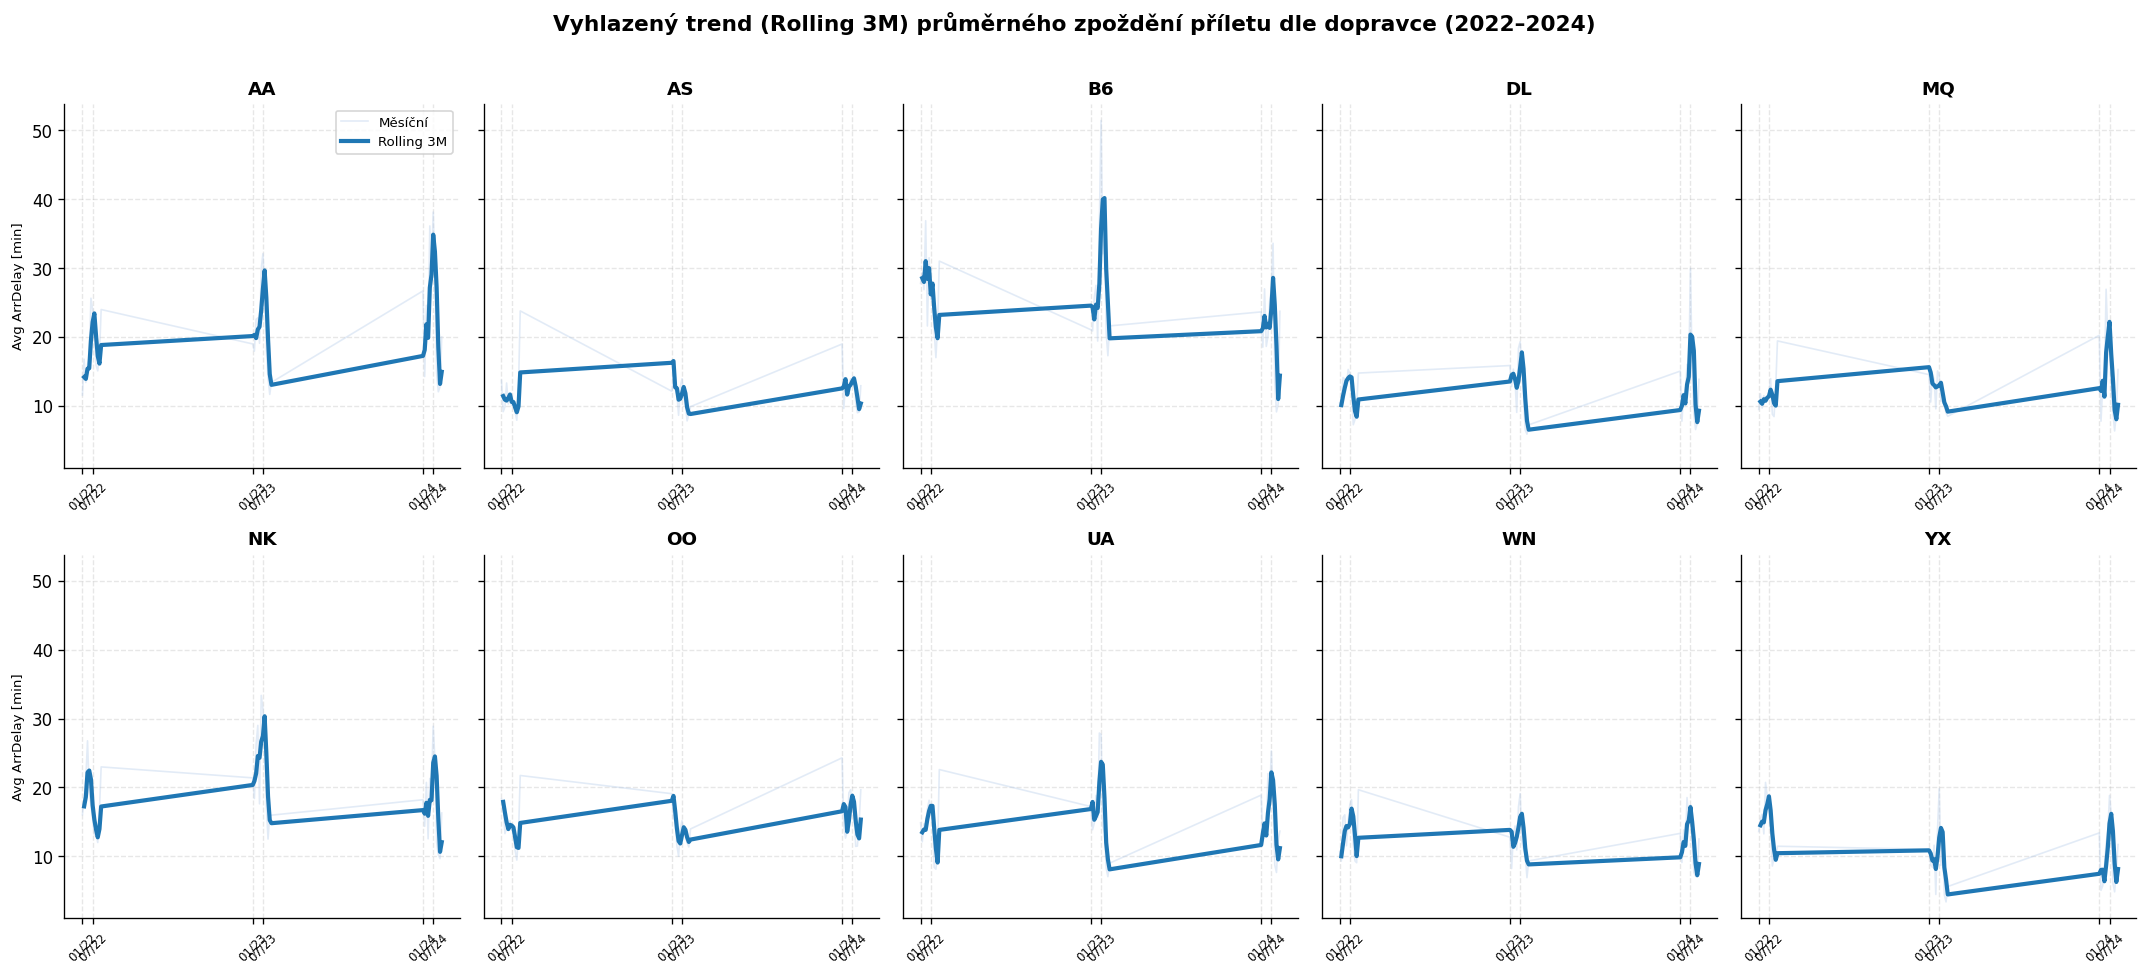

In [154]:
# BQ4 – Viz 3: Rolling 3M trend průměrného zpoždění dle dopravce
bq4_pivot = bq4_monthly.pivot_table(
    index="YearMonth", columns="Reporting_Airline",
    values="AvgArrDelay"
).sort_index()
bq4_rolling = bq4_pivot.rolling(3, min_periods=2).mean()

carriers_sorted = sorted(bq4_pivot.columns)
n = len(carriers_sorted)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
axes = axes.flatten()
ym_vals = bq4_pivot.index.tolist()

for i, carrier in enumerate(carriers_sorted):
    ax = axes[i]
    ax.plot(ym_vals, bq4_pivot[carrier], alpha=0.35, color="#aec7e8",
            linewidth=1, label="Měsíční")
    ax.plot(ym_vals, bq4_rolling[carrier], color="#1f77b4",
            linewidth=2.5, label="Rolling 3M")
    ax.set_title(carrier, fontsize=11, fontweight="bold")
    ax.set_xticks(ym_vals[::6])
    ax.set_xticklabels(
        [MONTH_LABELS.get(v, str(v)) for v in ym_vals[::6]],
        rotation=45, fontsize=7
    )
    ax.grid(linestyle="--", alpha=0.3)
    if i % ncols == 0:
        ax.set_ylabel("Avg ArrDelay [min]", fontsize=8)

# Skryj prázdné subploty
for j in range(n, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle("Vyhlazený trend (Rolling 3M) průměrného zpoždění příletu dle dopravce (2022–2024)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bq4_viz3_rolling3m.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 2.4 Interpretace a doporučení

### Hlavní zjištění

**Zjištění 1 (BQ1):** Pátek je systematicky nejproblematičtějším dnem v týdnu s nejvyšší hodnotou ArrDel15 Rate. Důkaz: graf ArrDel15 Rate dle dne (Viz 1 – BQ1). Provozní hustota na konci pracovního týdne kumuluje zpoždění, která se propagují přes celý systém. Management by měl cílit opatření zejména na páteční spoje, nikoliv plošně na celý týden.

**Zjištění 2 (BQ2):** Střední lety (500–1 500 mi) vykazují vyšší ArrDel15 Rate než krátké lety, zatímco dlouhé lety mají nižší průměrné zpoždění než střední – pravděpodobně díky větší časové rezervě a lepší možnosti kompenzace. Důkaz: Viz 1 a Viz 3 – BQ2. Distribuce délky let je silně asymetrická (průměr výrazně nad mediánem), proto by investiční rozhodnutí neměla vycházet z průměrů samotných.

**Zjištění 3 (BQ3):** Část dopravců systematicky kompenzuje zpoždění během letu (záporná hodnota Avg DelayDiff), zatímco jiní zpoždění průměrně zhoršují. Důkaz: scatter plot a sloupcový graf Viz 2 – BQ3. Schopnost kompenzace je klíčovým indikátorem operační efektivity a kvality plánování rotací.

**Zjištění 4 (BQ4):** Dopravci se výrazně liší nejen průměrnou úrovní ArrDel15 Rate, ale i stabilitou výkonu (StdDev). Někteří dopravci s relativně dobrým průměrem vykazují vysokou volatilitu (nespolehlivý provoz), zatímco jiní udržují konzistentní výkon i v sezónních špičkách. Důkaz: scatter výkon vs. stabilita (Viz 2 – BQ4).

---

### Konkrétní doporučení

**Doporučení 1 (→ BQ1):**  
*Doporučení:* U dopravců s nejvyšší páteční ArrDel15 Rate přezkoumat plánování rotací a bufferů mezi lety v páteční odpolední špičce.  
*Proč:* Pátek je systematicky nejhorší den – šíření zpoždění přes rotace zesiluje problém v průběhu odpoledne.  
*Dopad:* Snížení ArrDel15 Rate v pátek o 1–2 pp by u velkých dopravců zlepšilo zákaznickou zkušenost pro statisíce pasažérů.  
*Realizace:* Cílit na konkrétní letiště s vysokým páteční zatížením a konkrétní dopravce z BQ1 analýzy.

**Doporučení 2 (→ BQ2):**  
*Doporučení:* Pro KPI reporting a benchmarking nahradit průměrné zpoždění kombinací průměr + medián, zejména u krátkých letů.  
*Proč:* Distribuce `ArrDelayMinutes` je silně asymetrická – průměr je tažen nahoru extrémy (technické závady, počasí), medián lépe popisuje typický zážitek pasažéra.  
*Dopad:* Transparentnější KPI zabrání manipulaci reportingu a lépe odráží skutečnou zákaznickou zkušenost.  
*Realizace:* Aktualizovat dashboardy a smlouvy SLA na kombinaci obou metrik.

**Doporučení 3 (→ BQ3):**  
*Doporučení:* Dopravci s vysokou kladnou hodnotou Avg DelayDiff by měli prověřit plánování turnaround časů a rotací.  
*Proč:* Systematické zhoršování zpoždění během letu naznačuje nedostatečné rezervy nebo technické problémy, nikoli pouze zewnatrzní faktory.  
*Dopad:* Snížení Avg DelayDiff o 2–3 minuty by přineslo měřitelné zlepšení ArrDel15 Rate.  
*Realizace:* Audit plánování bloků na nejvíce postižených trasách (středně dlouhé lety).

**Doporučení 4 (→ BQ4):**  
*Doporučení:* Při výběru dopravce pro codeshare nebo strategické partnerství preferovat nejen průměrný výkon, ale i stabilitu (nízká StdDev).  
*Proč:* Dopravce s dobrou průměrnou spolehlivostí, ale vysokou volatilitou, je pro zákazníky nespolehlivý ve špičkách, kdy je spolehlivost nejkritičtější.  
*Dopad:* Snížení reklamací a kompenzací v sezónních špičkách.  
*Realizace:* Zahrnout StdDev jako standardní KPI do kvartálního hodnocení partnerů.

---

### Limity analýzy

**Limit 1 – Absence externího kontextu:**  
Analýza nepracuje s daty o počasí, kapacitě letišť ani vzdušného prostoru. Výkyvy v KPI (zejména letní špičky) mohou být primárně způsobeny externími faktory, nikoliv výkonem dopravce. Dopad: nelze rozlišit systémové od externích příčin zpoždění. Zmírnění: propojení s NOAA weather data nebo FAA OPSNET capacity data.

**Limit 2 – Průměry u asymetrických rozdělení:**  
Průměrné zpoždění je citlivé na extrémní hodnoty (lety s technickými závadami, přesměrování). Pro manažerská rozhodnutí je vždy uvádět medián vedle průměru. Dopad: průměr nadhodnocuje typické zpoždění. Zmírnění: přechod na percentilové KPI (P90, P95) pro smlouvy SLA.

**Limit 3 – Omezená kauzalita:**  
Analýza zjišťuje korelace (např. delší let – nižší ArrDel15 Rate), nikoli kauzální vztahy. Nelze tvrdit, že délka letu *způsobuje* menší zpoždění – mohou existovat confounders (např. trasy, časové pásmo, letiště). Dopad: doporučení jsou hypotetická, vyžadují A/B testování nebo regresní modely s kontrolou pro confounders. Zmírnění: multivariantní regresní analýza s kontrolou pro typ letiště, sezónu, dopravce.